In [1]:
import numpy as np
import pandas as pd
from math import *
#scipy stat

from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import expon,zscore,zmap
import matplotlib.pyplot as plt
import seaborn as sns
###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.stats.anova import anova_lm
from statsmodels.regression.linear_model import OLS
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import LeastSquares, HuberT, RamsayE, AndrewWave, TukeyBiweight,\
    TrimmedMean, Hampel
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from statsmodels.stats import stattools

from statsmodels.graphics.gofplots import qqplot_2samples,qqplot
from statsmodels.graphics.plot_grids import scatter_ellipse
from statsmodels.graphics.regressionplots import influence_plot, plot_leverage_resid2

from patsy import dmatrices,dmatrix

###################################################
'''sklearn'''
###################################################

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler                         
# linear_model
from sklearn.linear_model import Ridge,RidgeCV
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso
#decomposition
from sklearn.decomposition import PCA
import os

In [2]:

for dirname, _, filenames in os.walk('/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        print(path)

# Replace with the actual path printed above
path = '/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv'
df = pd.read_csv(path)

# Preview the data
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [3]:
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


#### 1. Find null values in dataset

In [5]:
# 1. Find null values in dataset
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

print("Missing Values in Dataset:\n", null_counts)
# Get numerical variables
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Get categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()


# 3. Frequency of each categorical variable
for col in categorical_vars:
    print(f"\nFrequency for {col}:")
    print(df[col].value_counts())


Missing Values in Dataset:
 Series([], dtype: int64)

Frequency for mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64

Frequency for guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

Frequency for basement:
basement
no     354
yes    191
Name: count, dtype: int64

Frequency for hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

Frequency for airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64

Frequency for prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64

Frequency for furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [6]:
categorical_vars = ['bedrooms', 'bathrooms', 'stories', 'parking']
for i, col in enumerate(categorical_vars):
    print(f'freqency of {df[col].value_counts()}')

freqency of bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64
freqency of bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64
freqency of stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64
freqency of parking
0    299
1    126
2    108
3     12
Name: count, dtype: int64


#### Null value analysis:

From the Bedrooms (frequency of occurrence) we can conclude - dataset is dominated by mid-sized family homes (2–3 bedrooms), while very small or very large homes are rare. You can see 6 bedrooms larger house have only 2 houses and Small house with 1 bedroom have only 2 houses.


From Bathrooms (frequency of occurrence) we can conclude that Most houses are basic builds with only one bathroom, showing affordability focus. Multi-bathroom houses are rare. You can see with 1 bathroom total 401 houses → majority while > 2 bathroom are in minority.

From Stories (frequency of occurrence) we conclude that dataset is evenly split between single-story and two-story houses, while taller houses (3–4 stories) are much less common.

From Parking (frequency of occurrence) we conclude that Parking availability is limited; most houses either have no parking or just one space.
i.e. - 0 parking spaces: 299 houses → over half


- The dataset reflects a mid-range housing market:
	- Most houses are 3-bedroom, 1-bathroom, 1–2 story homes.
	- Parking is scarce, with more than half of houses lacking dedicated spaces.
	- Luxury features (many bedrooms, bathrooms, parking spaces) are rare outliers.
	- This explains why earlier price contribution charts were dominated by mid-range categories — they occur most often.

#### See effect frequency of houses by bedroom count, split across three price categories (Lower, Medium, Higher), while also distinguishing whether the house is located on a main road (yes/no)

In [7]:
# Step 1: Define bins for price categories
# Adjust bins according to your dataset's price range
bins = [0, 2000000, 5000000, df['price'].max()]
labels = ['Lower', 'Medium', 'Higher']

# Step 2: Categorize price into bins
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)

# Step 3: Group by price_category, bedrooms, and mainroad
bedroom_freq = (
    df.groupby(['price_category', 'bedrooms', 'mainroad'], observed=True)
      .size()
      .unstack(fill_value=0)
)

tableDispFormatt("Frequency of bedrooms across price categories mainroad")
print(bedroom_freq)


bathrooms_freq = (
    df.groupby(['price_category', 'bathrooms', 'mainroad'], observed=True)
      .size()
      .unstack(fill_value=0)
)

tableDispFormatt("Frequency of bathrooms across price categories mainroad")
print(bathrooms_freq)

stories_freq = (
    df.groupby(['price_category', 'stories', 'mainroad'], observed=True)
      .size()
      .unstack(fill_value=0)
)

tableDispFormatt("Frequency of stories across price categories mainroad")
print(stories_freq)


=============================== Frequency of bedrooms across price categories mainroad =====
mainroad                 no  yes
price_category bedrooms         
Lower          2          1    3
               3          2    2
               5          1    0
Medium         1          1    1
               2         18  103
               3         36  135
               4         10   33
               5          2    1
               6          0    1
Higher         2          1   10
               3          1  124
               4          3   49
               5          1    5
               6          0    1
=============================== Frequency of bathrooms across price categories mainroad ====
mainroad                  no  yes
price_category bathrooms         
Lower          1           4    5
Medium         1          55  247
               2          10   26
               3           2    1
Higher         1           2   88
               2           4   93
              

#### Analysis main road effect concider only bedrooms:

**Mainroad effect**: Across all categories, houses on the main road are far more frequent, especially in medium and higher price ranges.

**Bedroom distribution:**

3‑bedroom houses dominate every price category. Larger homes (4–5 bedrooms) appear mostly in medium and higher categories.

**Market segmentation:**
- Lower category → small counts, scattered.
- Medium category → bulk of the dataset, dominated by 2–3 bedroom mainroad houses.
- Higher category → premium homes, almost all on mainroad.

#### analysis main road effect concider only bathrooms:

**Mainroad effect:** Across all categories, houses on the main road are far more frequent, especially in medium and higher price ranges.

- **Bathroom distribution:**
    - Lower category → almost exclusively 1 bathroom.
    - Medium category → dominated by 1 bathroom, with some 2 bathrooms.
    - Higher category → shift toward 2 bathrooms, with rare 3–4 bathroom luxury homes.

**Market segmentation:** Bathrooms act as a premium feature — more bathrooms appear only in higher price categories.


TODO:

Similarly we can see the effect of another categorical variable i.e. ['guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


#### Compute distribution statistics for the numerical variables in the House Prices dataset

- Skewness → Measures asymmetry of the distribution.
    - Positive skew = long right tail (common in price/area).
- Kurtosis → Measures “tailedness.”
    - High kurtosis = heavy tails/outliers.
- Z‑Score → Standardized score: 

    $\frac{x - \mu}{\sigma}$
    
    Shows how far a value is from the mean.
- IQR (Interquartile Range) → Spread between 75th percentile (Q3) and 25th percentile (Q1).
- CV (Coefficient of Variation) → Ratio of standard deviation to mean: $\frac{\sigma}{\mu}$ . Measures relative variability.


In [8]:
# Numerical variables
num_vars = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Create results dictionary
results = {}

for var in num_vars:
    data = df[var].dropna()
    
    # Skewness & Kurtosis
    skew_val = skew(data)
    kurt_val = kurtosis(data)
    
    # Z-Score (array of values)
    z_scores = zscore(data)
    
    # IQR
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    iqr_val = Q3 - Q1
    
    # Coefficient of Variation
    cv_val = np.std(data) / np.mean(data)
    
    results[var] = {
        'Skewness': round(skew_val, 2),
        'Kurtosis': round(kurt_val, 2),
        'IQR': round(iqr_val, 2),
        'CV': round(cv_val, 2),
        #'Z-Score (first 5)': np.round(z_scores[:5], 2)  # preview
    }

# Convert to DataFrame for display
stats_df = pd.DataFrame(results).T
print(stats_df)

           Skewness  Kurtosis        IQR    CV
price          1.21      1.93  2310000.0  0.39
area           1.32      2.72     2760.0  0.42
bedrooms       0.49      0.71        1.0  0.25
bathrooms      1.58      2.13        1.0  0.39
stories        1.08      0.66        1.0  0.48
parking        0.84     -0.58        1.0  1.24


Price and area show strong **positive skew and high kurtosis**, reflecting **luxury outliers**. Bathrooms also skew heavily toward single‑bathroom homes. Bedrooms and stories are more balanced. CV highlights that price and area have the highest relative variability.


#### Visualizations effect: 

#### Plot histograms with skewness and kurtosis annotations with numerical variable ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

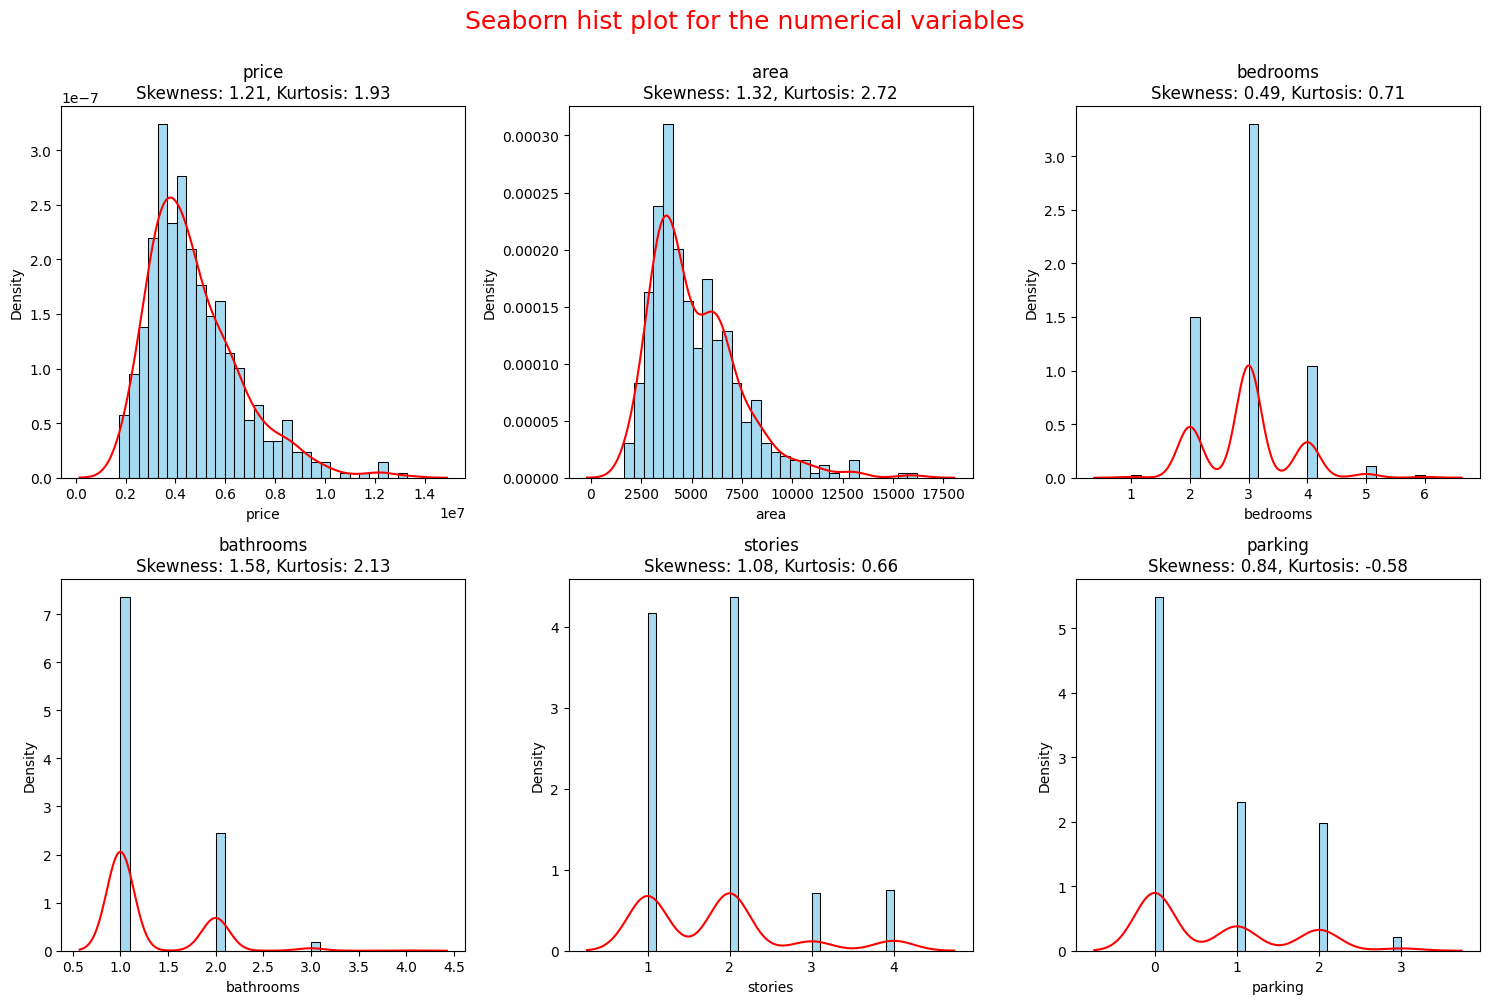

In [9]:
# Numerical variables
num_vars = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Plot histograms with skewness and kurtosis annotations
plt.figure(figsize=(15, 10))

for i, var in enumerate(num_vars, 1):
    plt.subplot(2, 3, i)
    
    # Histogram in skyblue
    sns.histplot(df[var], bins=30, color='skyblue', stat='density')
    
    # KDE overlay in red
    sns.kdeplot(df[var], color='red')
    
    # Calculate skewness and kurtosis
    skew_val = skew(df[var].dropna())
    kurt_val = kurtosis(df[var].dropna())
    
    # Annotate
    plt.title(f"{var}\nSkewness: {skew_val:.2f}, Kurtosis: {kurt_val:.2f}")
plt.suptitle(
    'Seaborn hist plot for the numerical variables',
    fontsize=18,
    color='red',
    y=1.0   # adjust distance (default ~1.0)
)
plt.tight_layout()
plt.show()

Histogram analysis shows that *price and area are heavily skewed with high kurtosis*, reflecting a few luxury properties. Bathrooms are *strongly skewed toward single‑bathroom homes*, while bedrooms and stories cluster around mid‑range values. *Parking distribution is flatter*, with most houses offering limited spaces. These insights suggest log transformation for price/area and categorical treatment for bathrooms and parking in predictive modeling.

- **Price & Area**: Both are heavily skewed with high kurtosis → log transformation may help normalize them before modeling.
- **Bathrooms**: Strong skewness shows most houses are basic (1 bathroom), with luxury homes rare.
- **Bedrooms & Stories**: More balanced, but still skewed toward mid‑range values.
- **Parking**: Flat distribution, showing limited variability (most homes have 0–2 spaces)


#### Hist plot & Kernel density plot to see effect different categorical variable on price

Also we investigate the skewness and kurtosis change with different categorical variable.

categorical variable = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
numerical variable = price

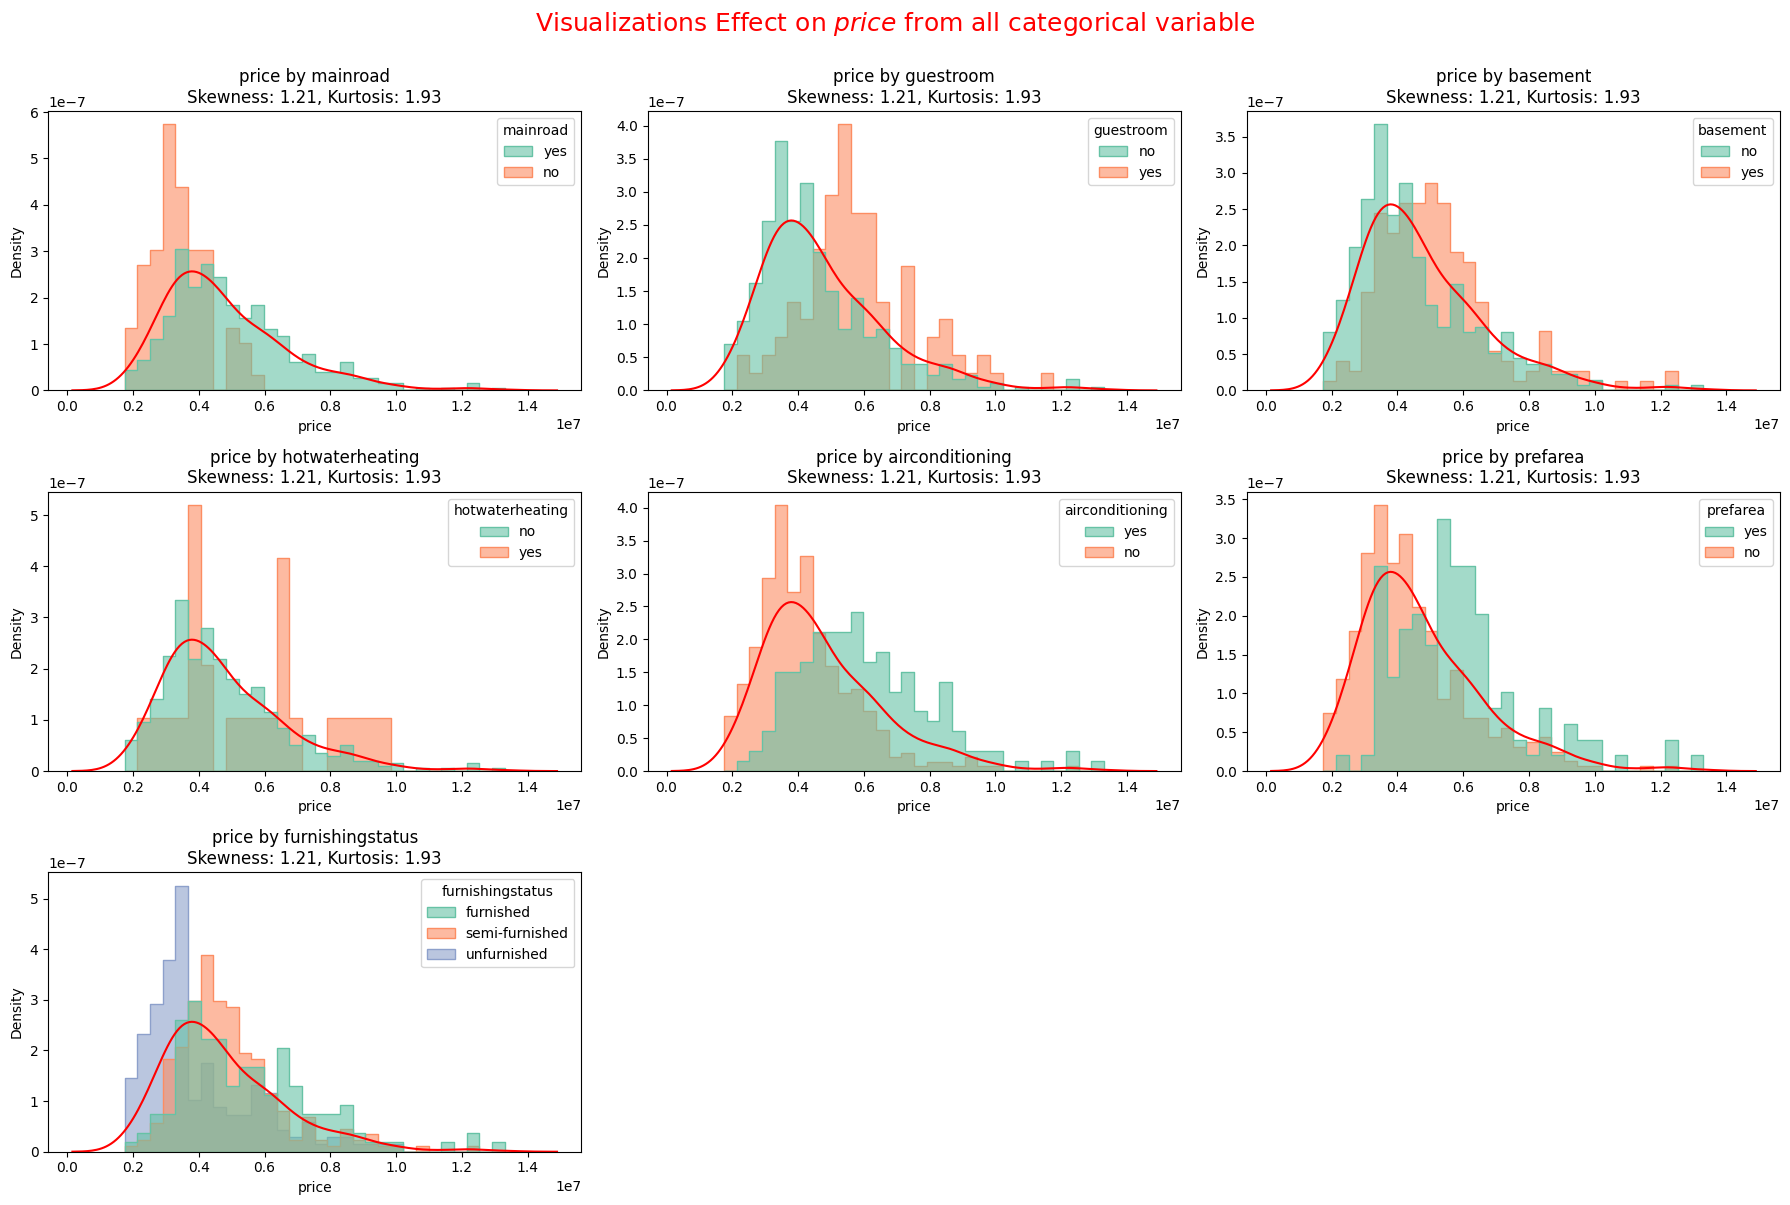

In [10]:
# Numerical variable
num_var = 'price'

# Hue variables
hue_vars = ['mainroad', 'guestroom', 'basement', 
            'hotwaterheating', 'airconditioning', 
            'prefarea', 'furnishingstatus']

plt.figure(figsize=(18, 12))

for i, hue_var in enumerate(hue_vars, 1):
    plt.subplot(3, 3, i)
    
    # Histogram with hue
    sns.histplot(data=df, x=num_var, hue=hue_var,element="step", bins=30, stat='density', 
                 palette='Set2',common_norm=False, alpha=0.6)
    
    # KDE overlay for overall distribution
    sns.kdeplot(df[num_var], color='red')
    
    # Calculate skewness and kurtosis
    skew_val = skew(df[num_var].dropna())
    kurt_val = kurtosis(df[num_var].dropna())
    
    # Annotate
    plt.title(f"{num_var} by {hue_var}\nSkewness: {skew_val:.2f}, Kurtosis: {kurt_val:.2f}")
plt.suptitle(
    'Visualizations Effect on $price$ from all categorical variable',
    fontsize=18,
    color='red',
    y=1.0   # adjust distance (default ~1.0)
)
plt.tight_layout()
plt.show()

Density plots show that categorical features like mainroad, prefarea, and airconditioning strongly shift housing prices upward. Guestroom and basement presence also add premiums, while furnishing status differentiates average price levels. These categorical variables are critical for predictive modeling, as they capture location and amenity-driven value.

- **Location features** (mainroad, prefarea) → biggest impact on price distribution.
- **Premium amenities** (airconditioning, basement, guestroom) → shift prices upward.
- **Rare features** (hotwaterheating) → small group but high-value impact.
- **Furnishing status** → semi-furnished dominates frequency, furnished homes command higher prices.
- **Overall distribution**: Price remains positively skewed (few luxury outliers) with moderate heavy tails.


#### Investigate Categoricasl variable on Area

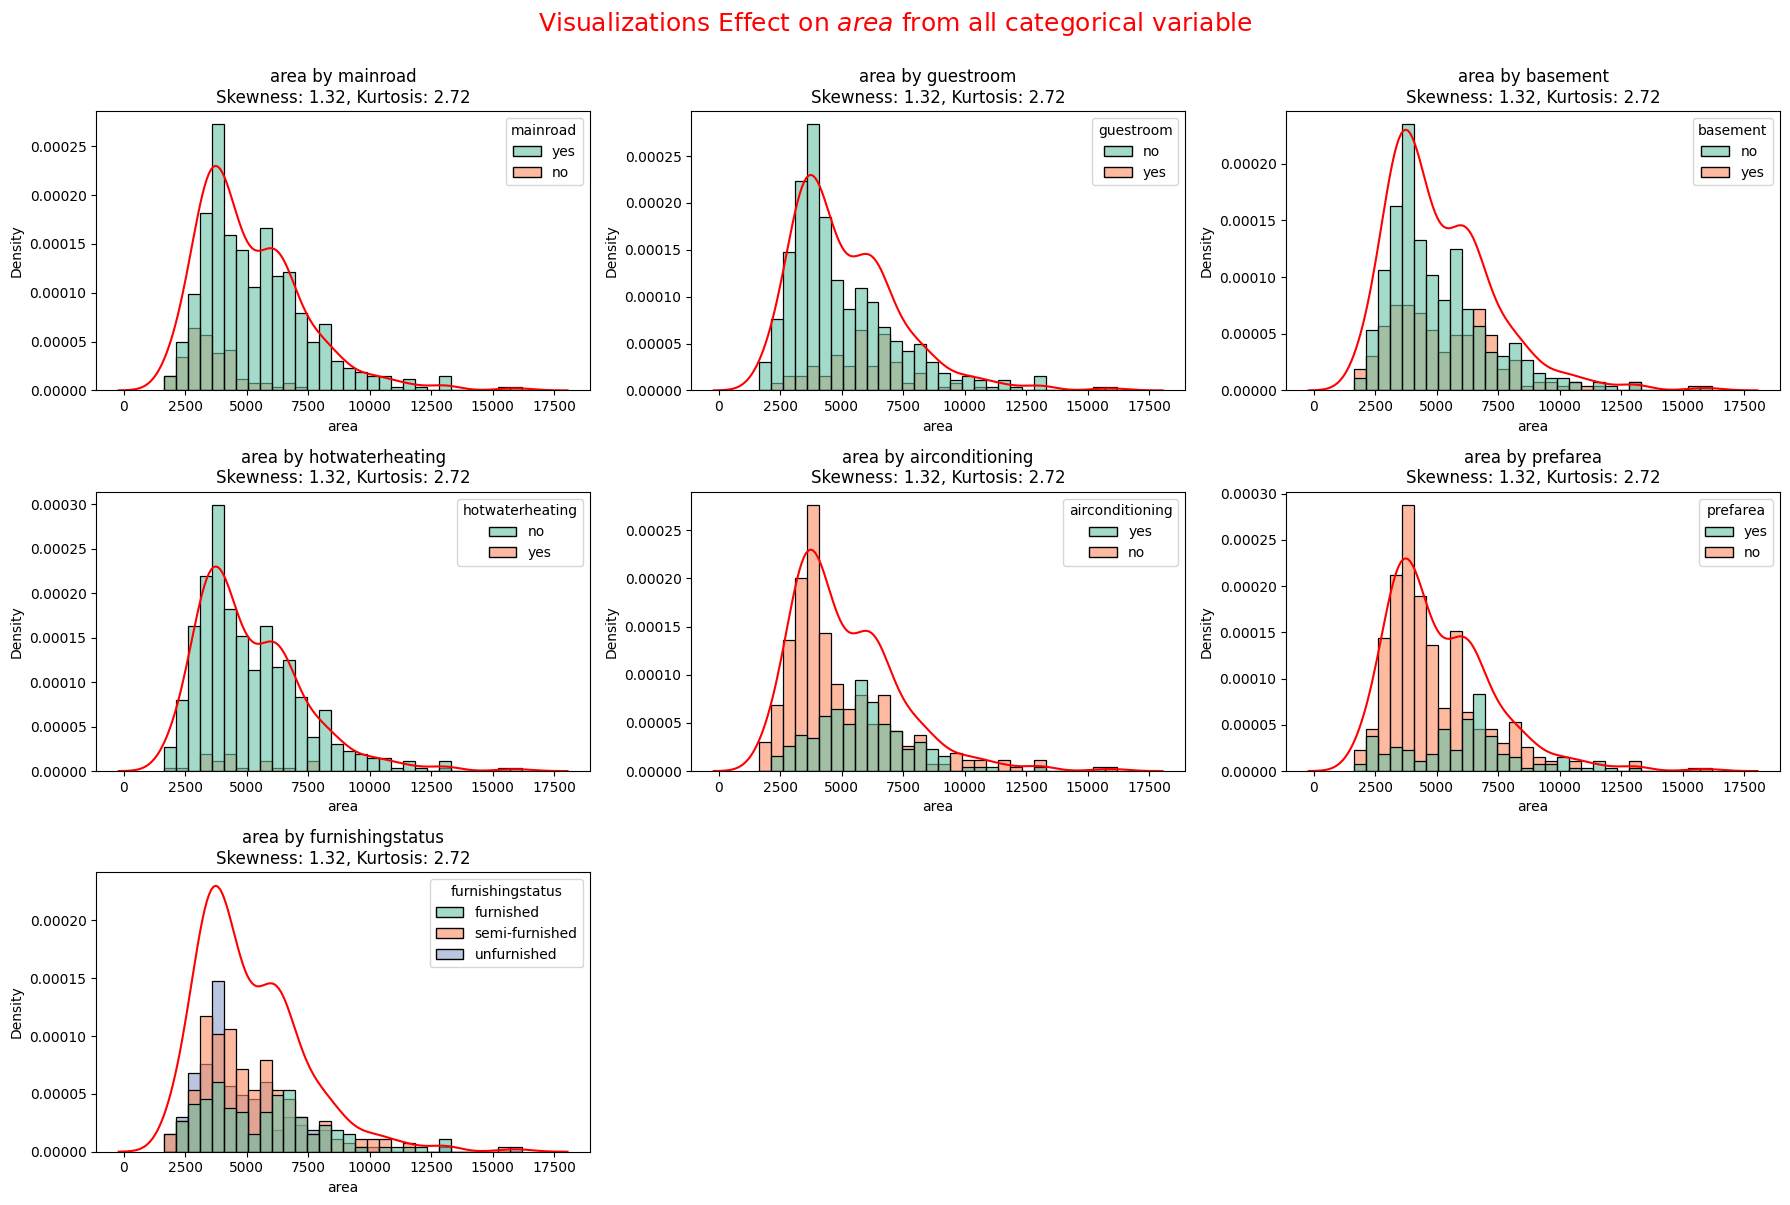

In [11]:
# Numerical variable
num_var = 'area'

# Hue variables
hue_vars = ['mainroad', 'guestroom', 'basement', 
            'hotwaterheating', 'airconditioning', 
            'prefarea', 'furnishingstatus']

plt.figure(figsize=(18, 12))

for i, hue_var in enumerate(hue_vars, 1):
    plt.subplot(3, 3, i)
    
    # Histogram with hue
    sns.histplot(data=df, x=num_var, hue=hue_var, bins=30, stat='density', 
                 palette='Set2', alpha=0.6)
    
    # KDE overlay for overall distribution
    sns.kdeplot(df[num_var], color='red')
    
    # Calculate skewness and kurtosis
    skew_val = skew(df[num_var].dropna())
    kurt_val = kurtosis(df[num_var].dropna())
    
    # Annotate
    plt.title(f"{num_var} by {hue_var}\nSkewness: {skew_val:.2f}, Kurtosis: {kurt_val:.2f}")
plt.suptitle(
    'Visualizations Effect on $area$ from all categorical variable',
    fontsize=18,
    color='red',
    y=1.0   # adjust distance (default ~1.0)
)
plt.tight_layout()
plt.show()

#### Z‑score density plot
A Z‑score density plot is a way of visualizing how far values in your dataset deviate from the mean, expressed in units of standard deviation. 

Z=$\frac{x-\mu }{\sigma }$

- Interpretation:
- Z=0 → exactly at the mean.
- Positive Z → above the mean.
- Negative Z → below the mean.
- Z > 2 or 3 → potential outliers.

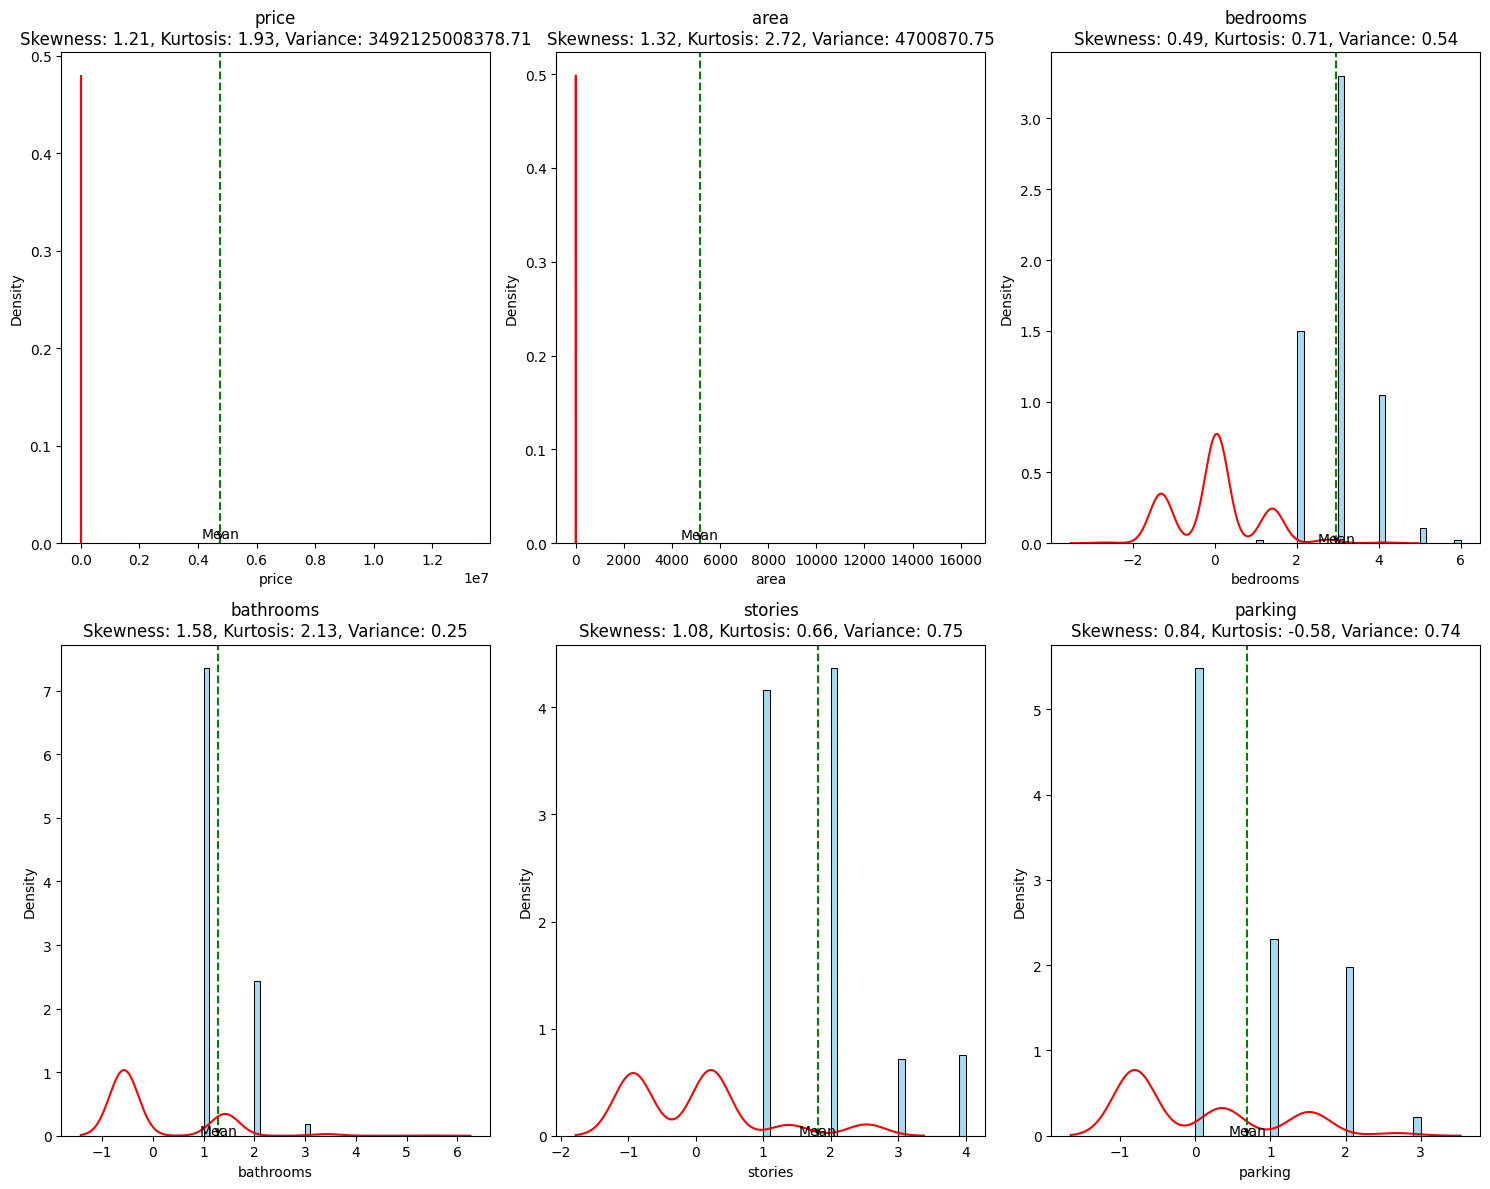

In [12]:
# Numerical variables
num_vars = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 12))

for i, var in enumerate(num_vars, 1):
    plt.subplot(2, 3, i)
    
    # Histogram of raw values
    sns.histplot(df[var], bins=30, color='skyblue', stat='density')
    
    # Overlay Z-score standardized distribution
    sns.kdeplot(zscore(df[var].dropna()), color='red', label='Z-score KDE')
    
    # Calculate statistics
    mean_val = df[var].mean()
    skew_val = skew(df[var].dropna())
    kurt_val = kurtosis(df[var].dropna())
    var_val = np.var(df[var].dropna())
    
    # Annotate skewness & kurtosis
    plt.title(f"{var}\nSkewness: {skew_val:.2f}, Kurtosis: {kurt_val:.2f}, Variance: {var_val:.2f}")
    
    # Arrow for mean
    plt.axvline(mean_val, color='green', linestyle='--')
    plt.annotate('Mean', xy=(mean_val, 0.001), xytext=(mean_val, 0.005),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 ha='center')

plt.tight_layout()
plt.show()

Z‑score density plots highlight that price and area distributions deviate strongly from normality, with positive skew and heavy tails due to luxury outliers. Bathrooms show similar skewness toward single‑bathroom homes. Bedrooms and stories cluster around mid‑range values, while parking is flatter with limited variability. These insights suggest log transformation for price/area and categorical encoding for bathrooms and parking in predictive modeling.

- **Price & Area**: Heavy positive skew → lots of houses below average, few extreme luxury outliers far to the right.
- **Bathrooms**: Strong skew → most homes have 1 bathroom, rare cases with 3–4 create long tails.
- **Bedrooms & Stories:** More balanced, but still skewed toward mid‑range values.
- **Parking**: Flatter distribution (negative kurtosis), showing limited variability and fewer extreme outliers.


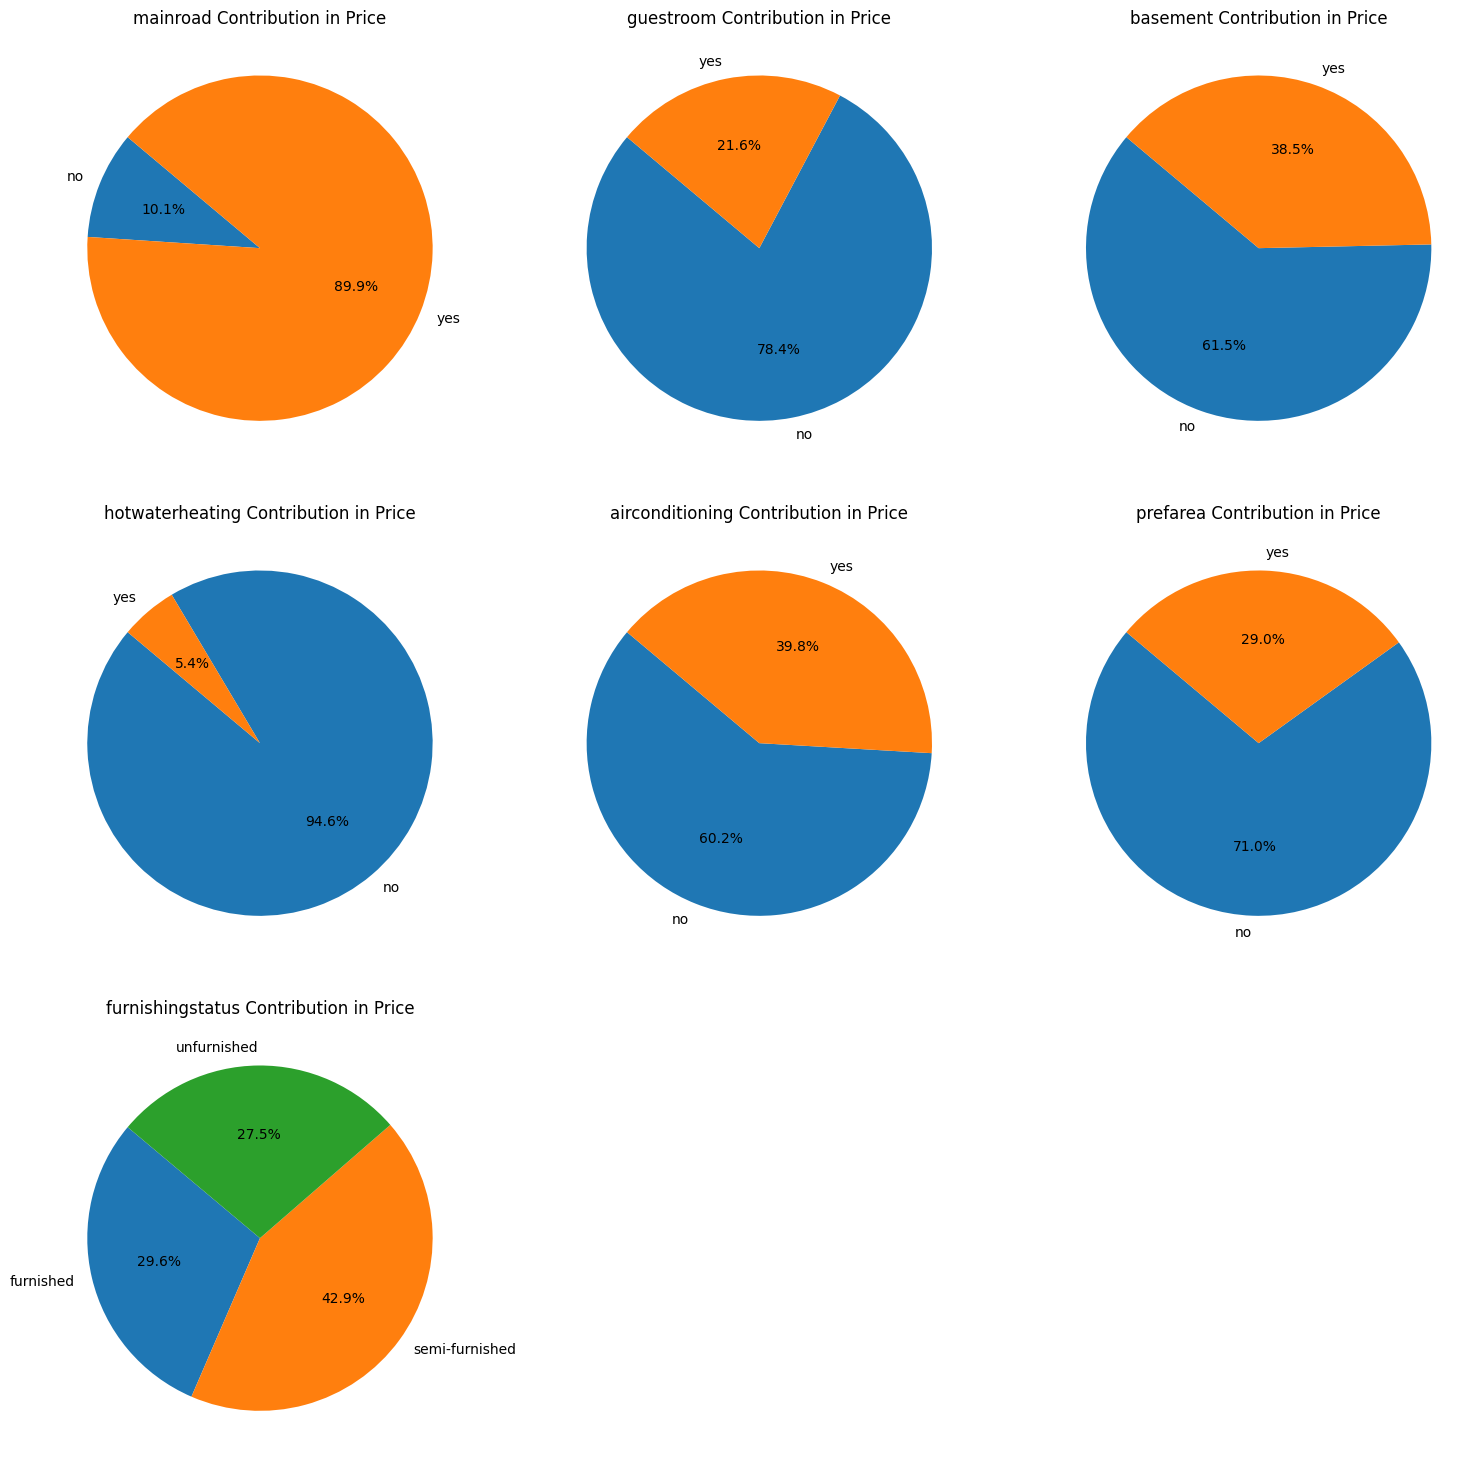

In [13]:
# List of categorical variables
categorical_vars = ['mainroad', 'guestroom', 'basement', 
                    'hotwaterheating', 'airconditioning', 
                    'prefarea', 'furnishingstatus']

# Define subplot grid (3 rows x 3 cols for 7 variables)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Loop through variables and plot pie chart
for i, col in enumerate(categorical_vars):
    price_contrib = df.groupby(col)['price'].sum()
    axes[i].pie(price_contrib, labels=price_contrib.index, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f"{col} Contribution in Price")

# Hide unused subplots (since we have 7 variables but 9 slots)
for j in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



Pie chart analysis highlights that location (mainroad, prefarea) and premium features (air conditioning, basements) drive the bulk of housing market value. Semi‑furnished homes dominate total contribution due to their frequency, while furnished homes command higher average prices. This distinction between average vs. aggregate contribution is critical for understanding housing market dynamics.

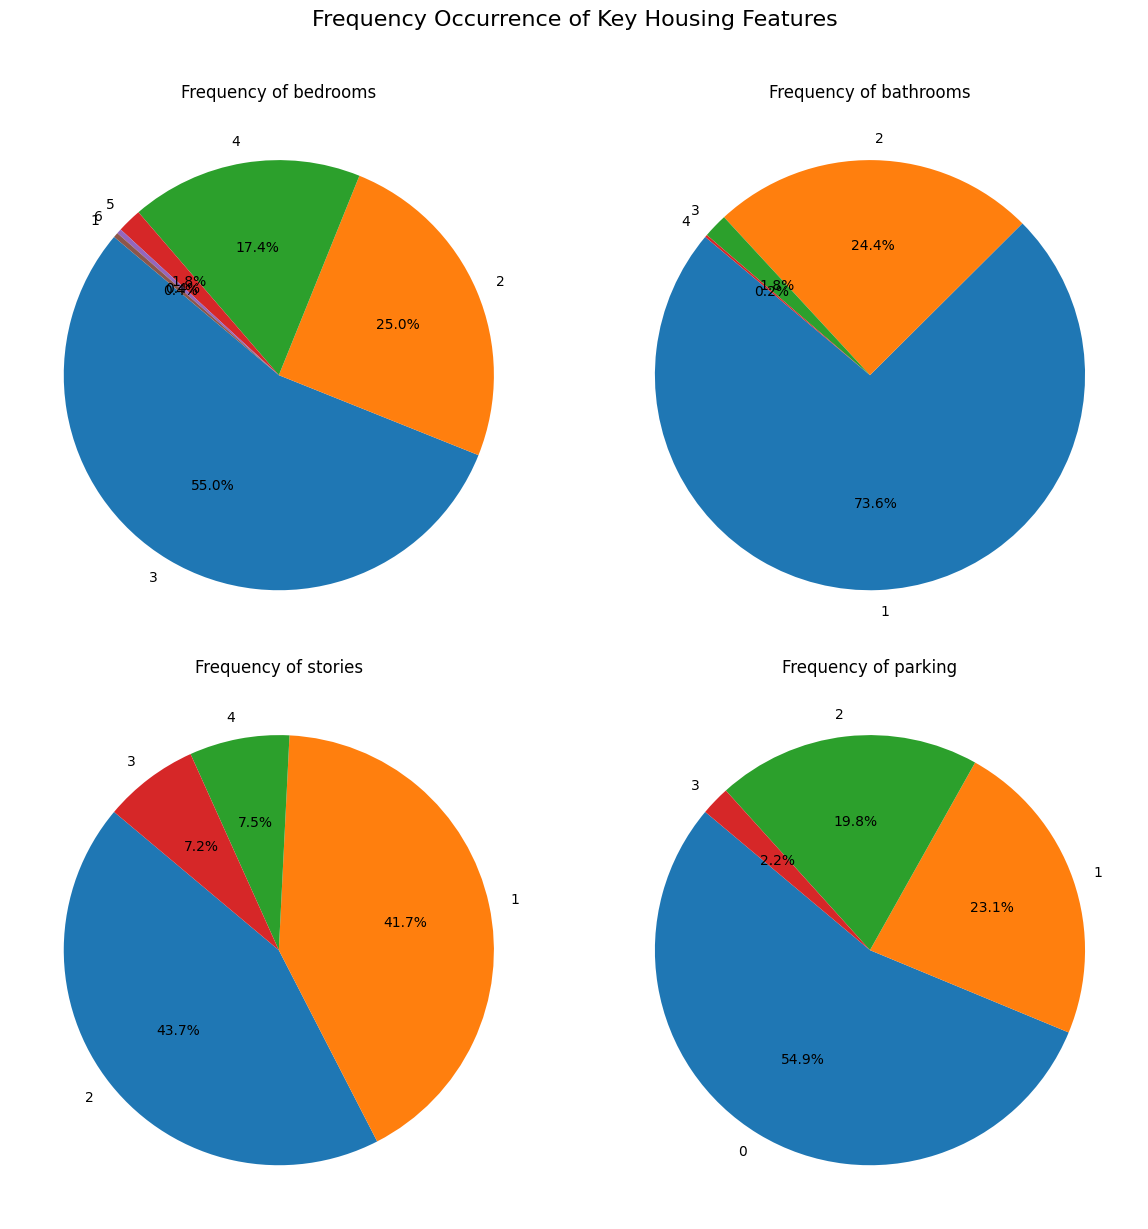

In [14]:
# Variables to plot
vars_to_plot = ['bedrooms', 'bathrooms', 'stories', 'parking']

# Create subplot grid (2x2 for 4 variables)
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

# Loop through variables and plot pie chart
for i, col in enumerate(vars_to_plot):
    freq_counts = df[col].value_counts()
    axes[i].pie(freq_counts, labels=freq_counts.index, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f"Frequency of {col}")
# Add a main title to the figure
plt.suptitle('Frequency Occurrence of Key Housing Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Explanation

**1. Bedrooms (Frequency of occurrence):**
    - 3 bedrooms: 55.0% → Most houses in the dataset are 3-bedroom homes.
    - 2 bedrooms: 25.0% → Second most common.
    - 4 bedrooms: 17.4% → Less frequent.
    - 5–6 bedrooms: Rare (≈2.6%).
    - 1 bedroom: Extremely rare (0.4%).

The dataset is **dominated by mid-sized family homes** (2–3 bedrooms)

**2. Bathrooms (Frequency of occurrence):**
    - 1 bathroom: 73.6% → Majority of houses have only one bathroom.
    - 2 bathrooms: 24.4% → A smaller but significant portion.
    - 3–4 bathrooms: Very rare (<2%).
Most houses are basic builds with limited bathrooms, showing affordability focus.

**3. Stories (Frequency of occurrence):**
    - 2 stories: 43.7%
    - 1 story: 41.7%
    - 3–4 stories: ≈15% combined.

The dataset is evenly split between single-story and two-story houses, with taller houses being uncommon.

**4. Parking (Frequency of occurrence):**
    - 0 parking spaces: 54.9% → **Over half of houses have no dedicated parking**.
    - 1 parking space: 23.1%
    - 2 parking spaces: 19.8%
    - 3 parking spaces: 2.2%

Parking availability is limited; most houses either have none or just one space

**The dataset reflects a mid-range housing market:**

Most houses are 3-bedroom, 1-bathroom, 1–2 story homes. Parking is scarce, with more than half of houses lacking dedicated spaces. Luxury features (many bedrooms, bathrooms, parking spaces) are rare outliers.
This distribution explains why price contributions earlier were dominated by mid-range houses - they are simply the most common.


In [15]:
# 1. Frequency percentage of bedrooms
freq_percentage = (df['bedrooms'].value_counts(normalize=True) * 100).round(2)

#print("Frequency percentage of bedrooms:\n")
#print(freq_percentage)

# 2. Average price grouped by bedrooms
avg_price = df.groupby('bedrooms')['price'].mean().round(2)

#print("\nAverage price by bedrooms:\n")
#print(avg_price)

# 3. (Optional) Average area grouped by bedrooms
avg_area = df.groupby('bedrooms')['area'].mean().round(2)

#print("\nAverage area by bedrooms:\n")
#print(avg_area)

# Combine into one summary DataFrame
summary = pd.DataFrame({
    'Frequency %': freq_percentage,
    'Average Price': avg_price,
    'Average Area': avg_area
})

print("\nSummary statistics grouped by bedrooms:\n")
print(summary)


Summary statistics grouped by bedrooms:

          Frequency %  Average Price  Average Area
bedrooms                                          
1                0.37     2712500.00       3710.00
2               24.95     3632022.06       4636.24
3               55.05     4954598.13       5226.62
4               17.43     5729757.89       5582.06
5                1.83     5819800.00       6291.50
6                0.37     4791500.00       3950.00


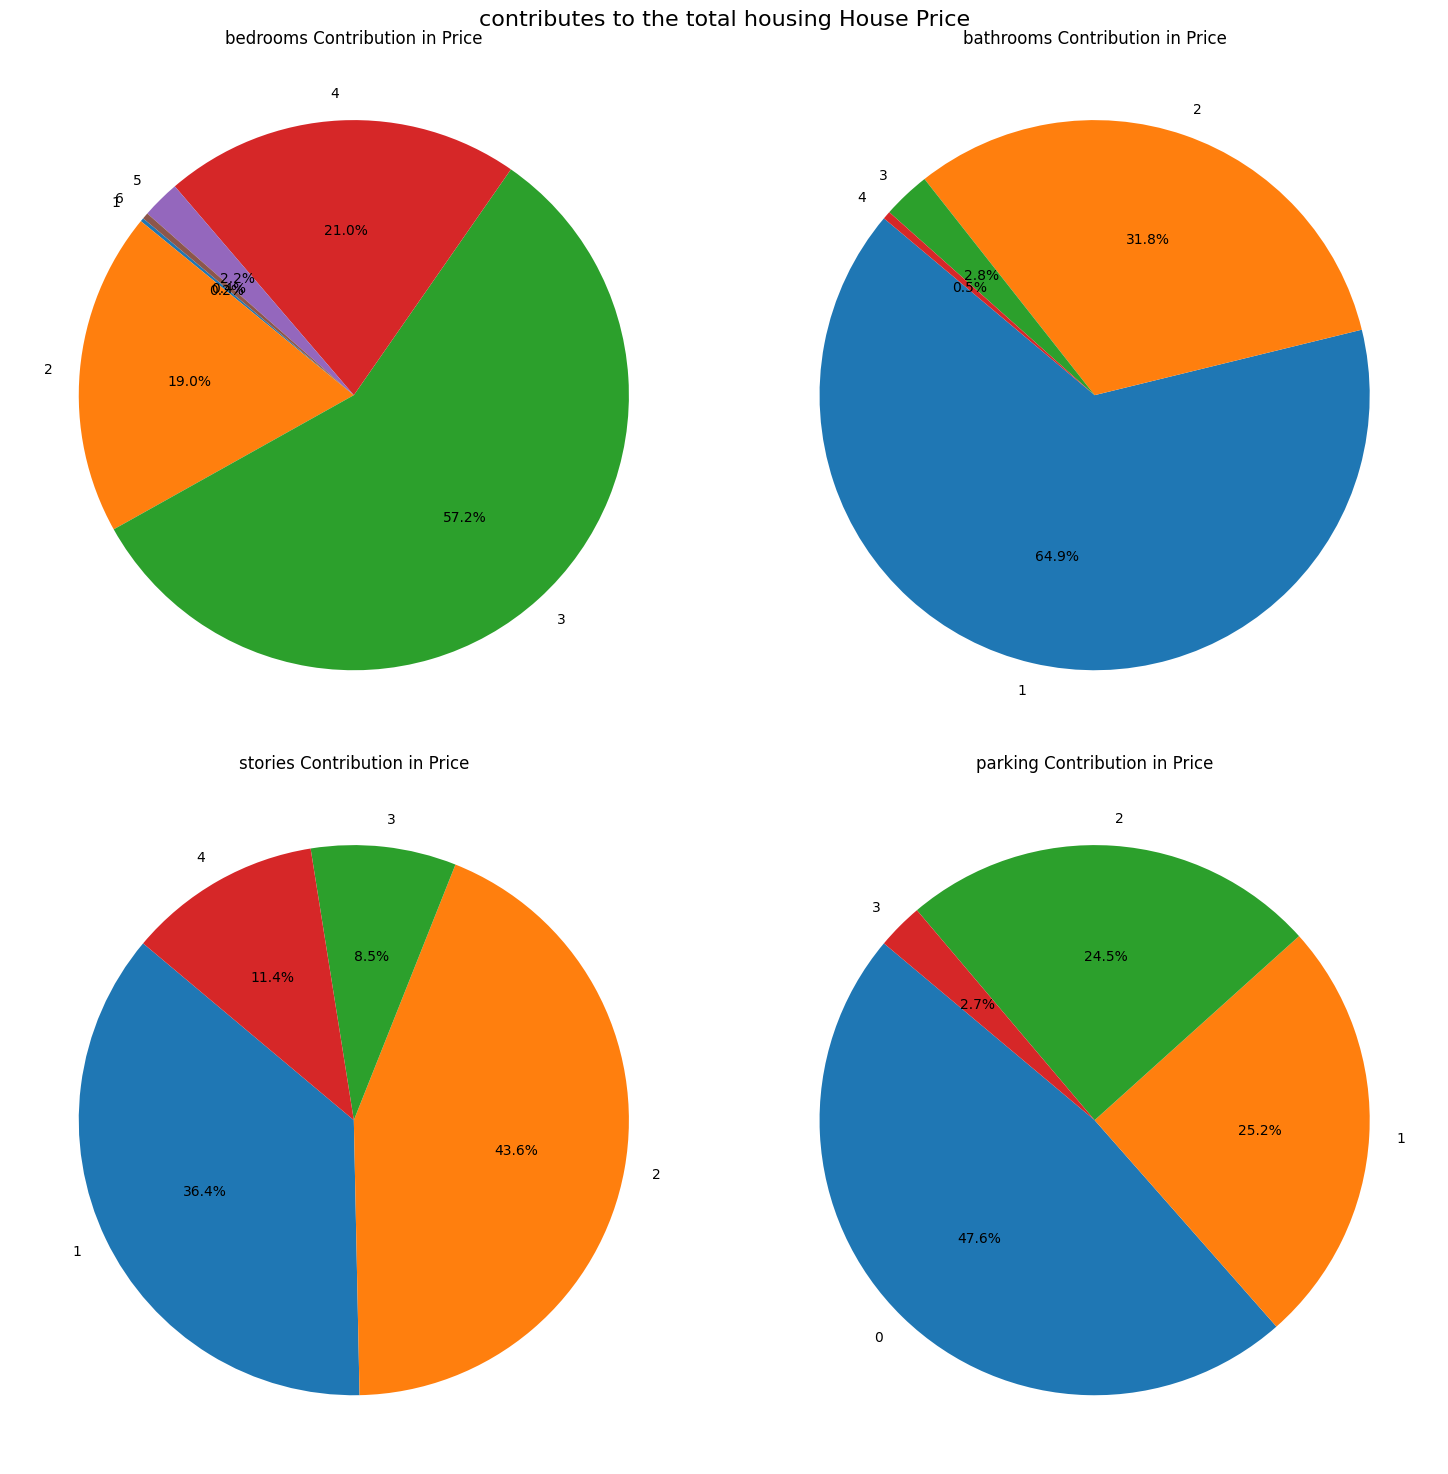

In [16]:
# List of categorical variables
categorical_vars = ['bedrooms', 'bathrooms', 'stories', 'parking']

# Define subplot grid (3 rows x 3 cols for 7 variables)
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()

# Loop through variables and plot pie chart
for i, col in enumerate(categorical_vars):
    price_contrib = df.groupby(col)['price'].sum()
    axes[i].pie(price_contrib, labels=price_contrib.index, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f"{col} Contribution in Price")

# Hide unused subplots (since we have 7 variables but 9 slots)
for j in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('contributes to the total housing House Price', fontsize=16)
plt.tight_layout()
plt.show()

What These Charts Reveal
  - These are total price contributions, not average prices or frequency.
  - Categories like 3 bedrooms, 1 bathroom, 2 stories, and 0 parking dominate because they are most common and collectively valuable.
  - Luxury features (more bedrooms, bathrooms, parking) exist but contribute less due to rarity.

Contribution analysis shows that 3‑bedroom, 1‑bathroom, 2‑story houses dominate total housing value. Parking availability is split, with nearly half of houses lacking parking but 1–2 spaces contributing significantly. These distributions highlight the typical mid‑range house profile in the dataset.

### Visualizations multi-dimensional relationships by using Seaborn

Showing multi-dimensional relationships housing price and area, where the number of columns dependents upon total maximum number of bead room available in houses i.e. 6. Where columns Splits plots into two panels, houses on the main road vs. not on the main road.

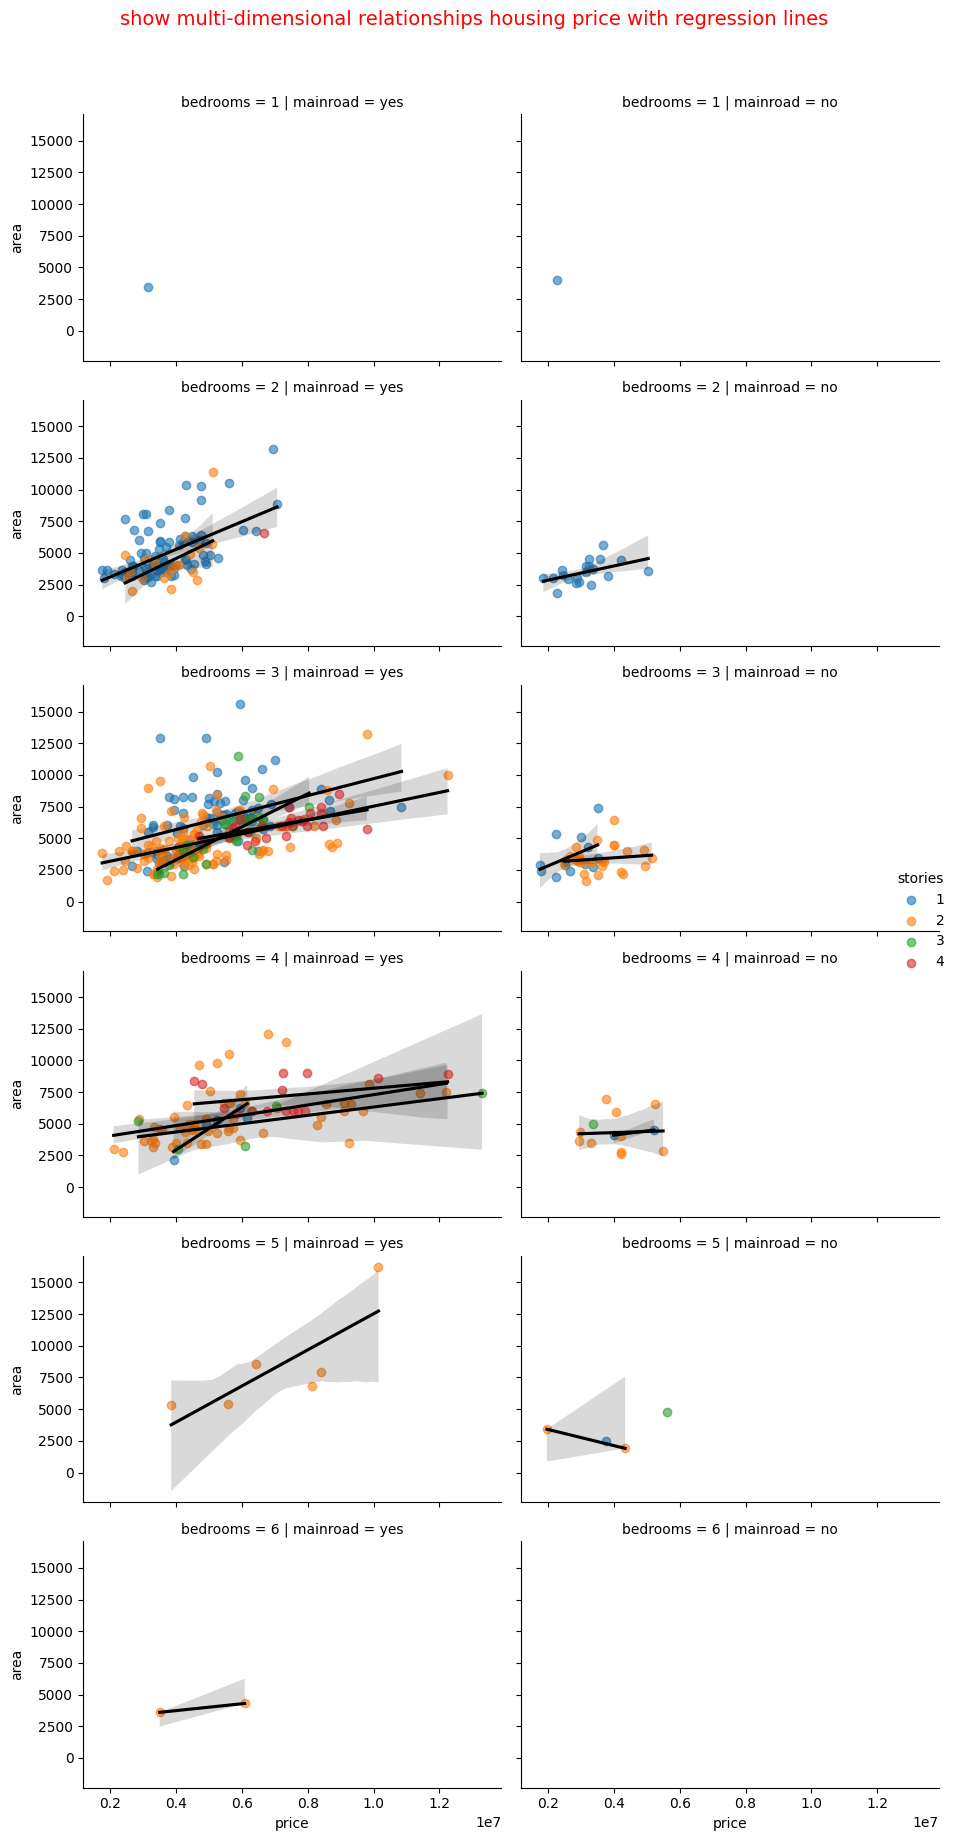

In [17]:
sns.lmplot(
    data=df,
    x="price",
    y="area",
    hue="stories",       # color by number of stories
    col="mainroad",      # facet by mainroad status
    row="bedrooms",      # facet by bedrooms
    height=3,            # height of each facet
    aspect=1.5,          # width/height ratio
    scatter_kws={"alpha":0.6},  # transparency for points
    line_kws={"color":"black"}  # regression line style
)

plt.suptitle(
    'show multi-dimensional relationships housing price with regression lines',
    fontsize=14,
    color='red',
    y=1.02
)

plt.tight_layout()
plt.show()

#### What the Plot Show

- X-axis: price → the selling price of houses.
- Y-axis: area → the size of the house in square feet.
- Hue (color): stories → number of stories in the house, with different shades representing 1, 2, 3, or 4 stories.
- Columns (col="mainroad"): Splits plots into two panels: houses on the main road vs. not on the main road.
- Rows (row="bedrooms"): Each row corresponds to a different number of bedrooms (1 through 6).

**- Price vs. Area Relationship:**
    - Generally, larger area houses tend to have higher prices, but the slope varies across categories.
    - Impact of Mainroad:
    - Houses on the main road often cluster at higher prices for similar areas, showing location premium.
    - **Regression lines** show that larger area generally corresponds to higher price.
    - The **slope of each line indicates how strongly area drives price** in that category.

**- Bedrooms:**
    - As bedroom count increases (moving down rows), houses tend to cluster at larger areas and higher prices.
    - **Regression lines shift upward**, reflecting higher average prices for more bedrooms.
    
**- Stories (color hue):**
    - Multi‑story houses often cluster at higher prices for similar areas.
    - More stories often correspond to higher prices, even for similar areas.
    - Visually compare how multi-story houses cluster differently than single-story ones.
    - The color separation lets you see how stories interact with area and price across categories.

**- Impact of Mainroad:**
- Houses on the **main road often show steeper slopes or higher intercepts**, meaning **location adds a premium**.


**Helps identify patterns and outliers: e.g., unusually expensive small houses, or large houses with surprisingly low prices**.


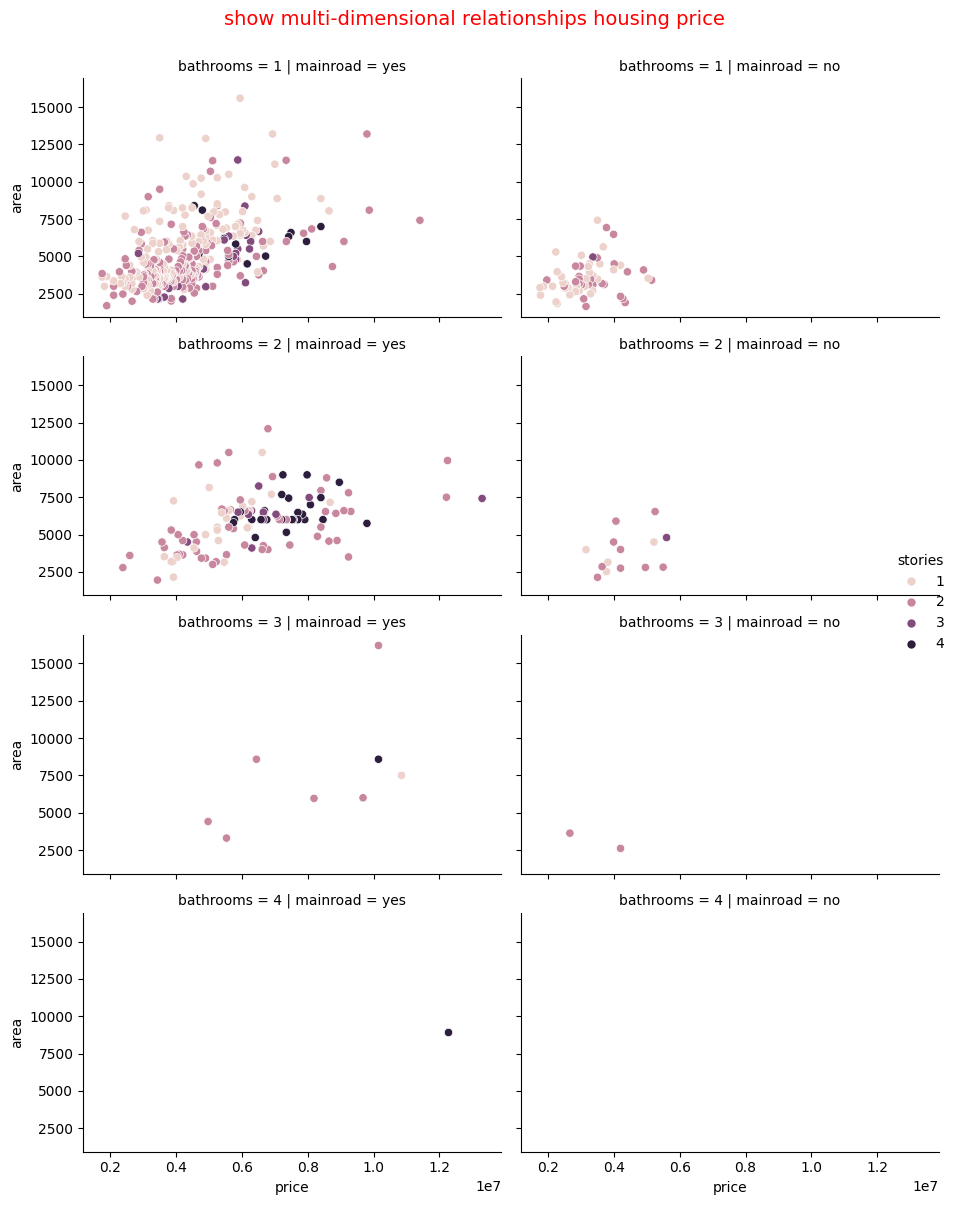

In [18]:
sns.relplot(
    data=df,
    x="price",
    y="area",
    hue="stories",
    col="mainroad",
    row="bathrooms",
    height=3,
    aspect=1.5
)

# Add subtitle with red color and spacing
plt.suptitle(
    'show multi-dimensional relationships housing price',
    fontsize=14,
    color='red',
    y=1.0   # adjust distance (default ~1.0)
)

plt.tight_layout()
plt.show()


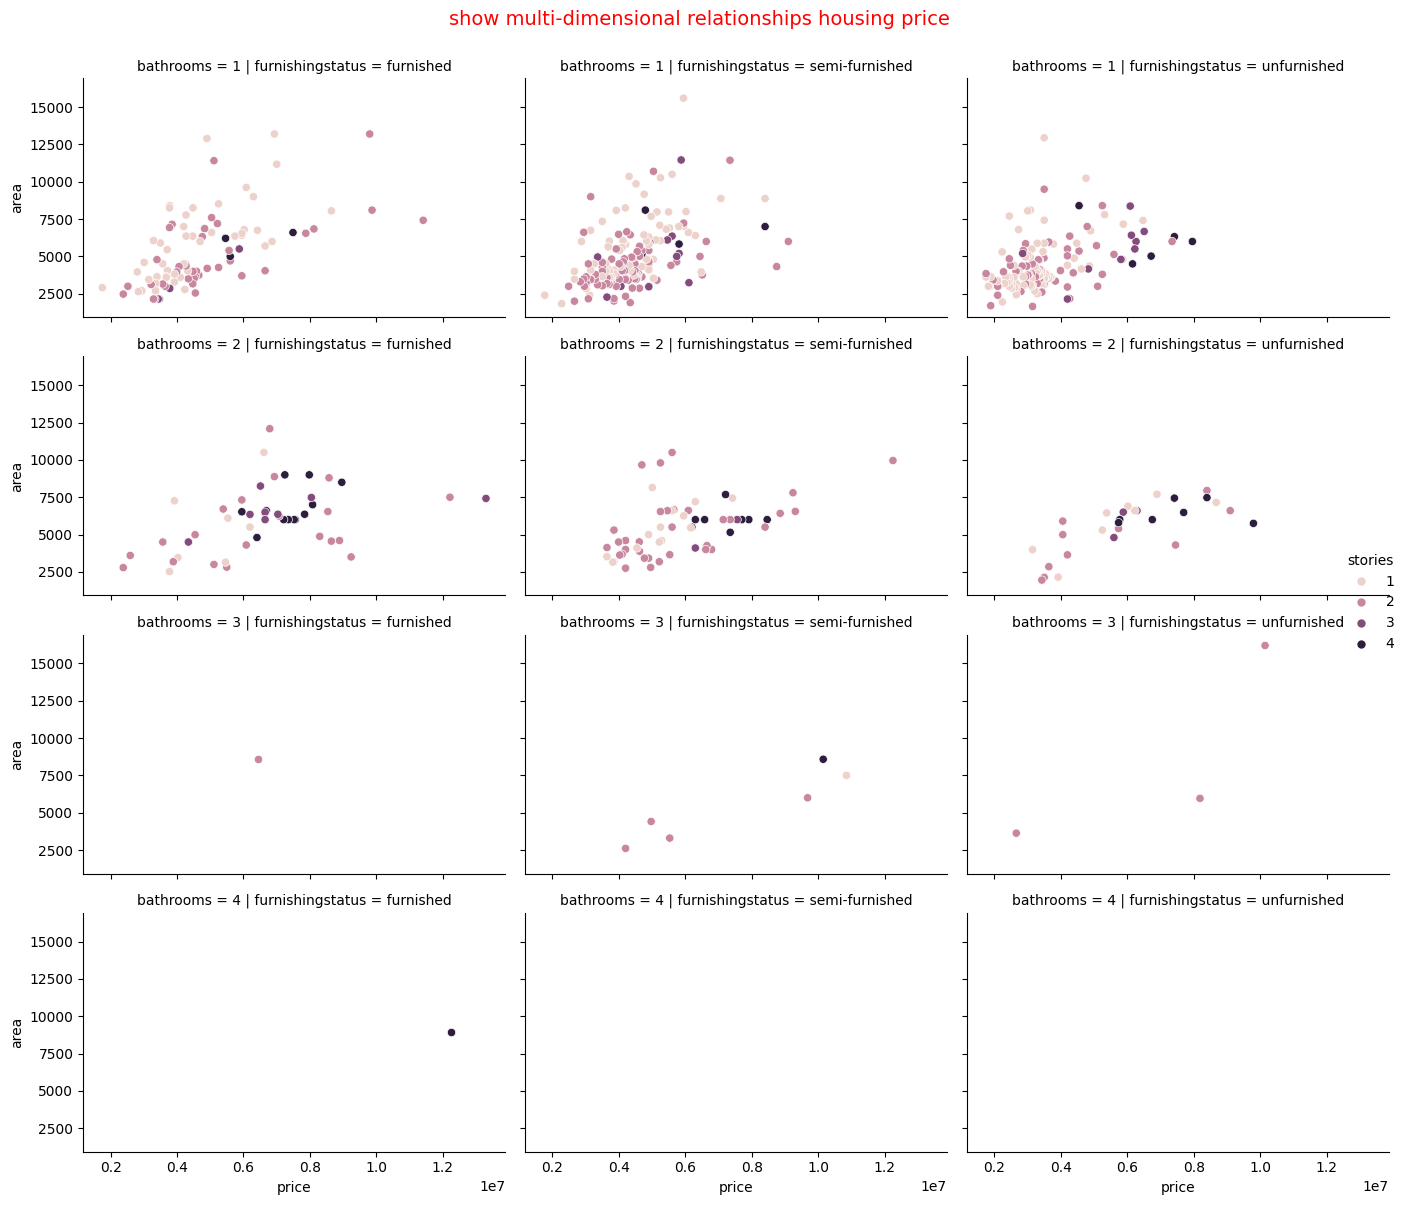

In [19]:
sns.relplot(
    data=df,
    x="price",
    y="area",
    hue="stories",
    col="furnishingstatus",
    row="bathrooms",
    height=3,
    aspect=1.5
)
# Add subtitle with red color and spacing
plt.suptitle(
    'show multi-dimensional relationships housing price',
    fontsize=14,
    color='red',
    y=1.0   # adjust distance (default ~1.0)
)

plt.tight_layout()
plt.show()

In [20]:
# Group by furnishingstatus and calculate mean price
mean_prices = df.groupby('furnishingstatus')['price'].mean().round(2)

print("Mean house price by furnishing status:\n")
print(mean_prices)

Mean house price by furnishing status:

furnishingstatus
furnished         5495696.00
semi-furnished    4907524.23
unfurnished       4013831.46
Name: price, dtype: float64


- Furnishing Status:
    - Furnished houses generally cluster at higher prices than semi‑furnished or unfurnished ones, even for similar areas.
    - This highlights furnishing as a premium feature.

Here is the one hack!!! We have already seen in our pie chart semi-furnished house showing more contributions in housing price.

***Qus: Explain why mean of price is higher in furnished, while pie chart show the higher contributions of semi-furnished in housing price?***

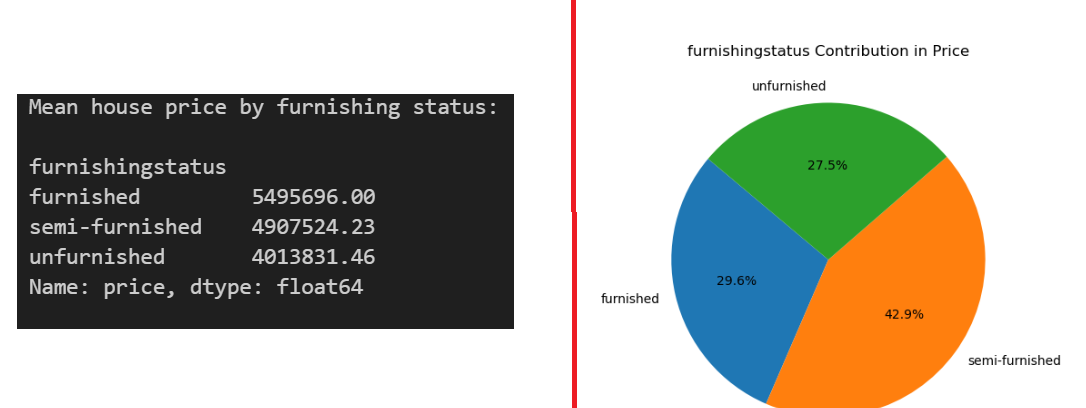

##### Why Furnished Has Higher Mean Price?

Mean price is the average price per house in that category.Furnished houses **tend to be individually more expensive** because they include premium amenities and convenience. Even if there are fewer furnished houses, each one costs more on average, so the mean is higher.

##### Why Semi‑Furnished Shows Higher Contribution in Pie Chart?

The pie chart you plotted is based on **total contribution to housing price** (sum of all prices in each category). **Semi‑furnished houses are more numerous** in the dataset compared to furnished ones. Even though each semi‑furnished house is cheaper on average, their large count adds up to a bigger share of total market value. That’s why semi‑furnished dominates the pie chart contribution.


# Final Conclusion on House Prices Dataset overall analysis

##### Summery Report

#### Market Profile:
The dataset reflects a mid‑range housing market dominated by 3‑bedroom, 1‑bathroom, 1–2 story homes. Parking is scarce, with over half of houses lacking dedicated spaces. Luxury features (many bedrooms, bathrooms, parking spaces, hot water heating) are rare outliers.

#### Numerical Variables:

1. **Price & Area:** Both are positively skewed with high kurtosis, driven by a few luxury properties. 
2. **Bathrooms**: Strong skew toward single‑bathroom homes, highlighting affordability focus.
3. **Bedrooms & Stories:** More balanced, but still skewed toward mid‑range values.
4. **Parking**: Flat distribution, showing limited variability (most homes have 0–2 spaces).
5. **Correlation analysis**:
    - **Strongest drivers of price** → area (0.536) and bathrooms (0.518).
    - **Moderate influence** → stories (0.421) and parking (0.384).
    - Bedrooms have weaker correlation with price (0.366).
    - ***Multicollinearity risk exists between bedrooms ↔ bathrooms ↔ stories.***

#### Visual Insights

**Histograms & KDE plots:** Confirm skewness and heavy tails in price/area.

**Density plots:** Show categorical features shifting price upward.

**Pair plots:** Validate that area and bathrooms are strongest predictors, while bedrooms, stories, and parking provide moderate influence.

**Pie charts:** Contribution analysis dominated by mid‑range categories due to frequency, not average price.

#### **Business Interpretation:**

**Size and amenities drive value**: Larger area and more bathrooms are the clearest signals of higher price.

**Location premiums**: Houses on the main road or in preferred areas consistently command higher prices.

**Market dominated by mid‑range homes**: Most houses are affordable builds with limited luxury features, explaining why aggregate contributions are skewed toward common categories.


The House Prices dataset reveals a mid‑range housing market where size (area, bathrooms) and location (mainroad, prefarea) are the strongest drivers of value. Most homes are modest builds with limited parking and basic amenities, while luxury features are rare but impactful. Predictive modeling should focus on area, bathrooms, and location features, with transformations applied to skewed variables, to accurately capture housing price dynamics.


#### Multicollinearity

For addressing multicollinearity through PCA-based feature selection, I have considered two types of models:
- Model 1 – Two-line solution models
- Model 2 – Single-line solution models (including interaction-term models)

Before proceeding, we first need to clarify the meaning of single-line and two-line models.

#### Indicator variable with single line and two line models approch:

We apply one-hot encoding to transform categorical variables into numerical variables. This process is called one-hot encoding. The resulting indicator variables are often referred to as dummy variables.

#### Q1: Explain mathematically why indicator (dummy) variables are required in statistical and machine learning models.

Now take 3 variable from housing Dataset 
- Horse power, accelerations     ==> Numerical variable
- origin                         ==> Categorical variable

now assume Let $y$ == mpg; $x_1$ == Horse powerea, $x_2$ == accelerations

So regressions models equations

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon $  ---- (i)

Now let origin i.e. $x_2$ have only two params i.e. YES and NO. Let assume YES = 1 & NO = 0

Now we can write equations (i)  when $x_2$ = YES = 1 in this situations equations (i) become

- $y = \beta_0 + \beta_1 x_1 + \beta_2*1 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \beta_2 + \varepsilon$
- $y = (\beta_0 + \beta_2) + \beta_1 x_1 + \varepsilon$  ----(ii)

when $x_2$ = NO = 0 in this situations equations (i) become
- $y = \beta_0 + \beta_1 x_1 + \beta_2*0 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \varepsilon$   ---- (iii)

Equations (ii) and (iii) have the same slope i.e. $\beta_2$ and different intercept i.e. equations (ii) intercept = $(\beta_0 + \beta_2)$ and equations (iii) have intercept = $\beta_0$.

SO equations (ii) and (iii) have common slope and different intercept. Hack!!! conditions of parallel line. This situations called two-line solutions — the regression model fits two parallel lines, one for each category 

Since both straight lines are assumed to have the same slope, it makes sense to combine the data from both mainroad types to produce a single estimate of this common parameter. This approach also gives one estimate of the common error variance σ² and more residual degrees of freedom than would result from fitting two separate regression lines.

Furthermore, **Multicollinearity risk** If you create dummy variables for all categories, you get perfect collinearity (the "dummy variable trap"). That’s why we drop one category as the baseline. **Interpretation challenge** The regression line splits into multiple lines depending on categories, which complicates interpretation if you don’t understand dummy coding.

Single-model approach is preferred because the analyst has only one final equation to work with instead of two, a much simpler practical result.

Qus: How we can achieve Single-model approach ?

Now we need to use one hot encoding tecgnique. This will modify the equations (i)

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1 x_2 + \varepsilon$  ---- (iv) 

Now first considered main road face not available with house i.e. $x_2 = 0$ So equations (iv) become

- $y = \beta_0 + \beta_1 x_1 + \beta_2*0 + \beta_3 x_1*0 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \varepsilon$   ----- (v)

considered main road face available with house i.e. $x_2 = 1$ So equations (iv) become
- $y = \beta_0 + \beta_1 x_1 + \beta_2*1 + \beta_3 x_1*1 + \varepsilon$
- $y = (\beta_0 + \beta_2) + \beta_1 x_1 + \beta_3 x_1*1 + \varepsilon$
- $y = (\beta_0 + \beta_2) + (\beta_1 + \beta_3) x_1 + \varepsilon$   --- (vi)

A miracle has happened in the equations (vi). 

You can see slope of equations (v) $\beta_1$ and slope of equations (vi) $(\beta_1 + \beta_3)$.Slope are different and intercept of equations (v) $\beta_0$ and intercept of equations (vi) $(\beta_0 + \beta_2)$.

So this called Single-model approach.

Two line solutions regression equation:

$Y=\beta _0+\beta _1\cdot \mathrm{AR}+\beta _2\cdot \mathrm{BD}+\beta _3\cdot \mathrm{BT}+\beta _4\cdot \mathrm{ST}+\beta _5\cdot \mathrm{PARK}+\gamma _1\cdot \mathrm{MRD}+\gamma _2\cdot \mathrm{GR}+\gamma _3\cdot \mathrm{BS}+\gamma _4\cdot \mathrm{HW}+\gamma _5\cdot \mathrm{AC}+\gamma _6\cdot \mathrm{PAREA} +\gamma _7\cdot \mathrm{FSS}+\gamma _8\cdot \mathrm{FSU}+\epsilon$ 

Single Line Solutions Regressions equations Models:

$\begin{aligned}Y&=\beta _0+\beta _1\cdot AR+\beta _2\cdot BD+\beta _3\cdot BT+\beta _4\cdot ST+\beta _5\cdot PARK\\ &+\gamma _1\cdot (AR\cdot MRD)+\gamma _2\cdot (AR\cdot GR)+\gamma _3\cdot (AR\cdot BS)+\gamma _4\cdot (AR\cdot HW)+\gamma _5\cdot (AR\cdot AC)+\gamma _6\cdot (AR\cdot PAREA)+\gamma _7\cdot (AR\cdot FSS)+\gamma _8\cdot (AR\cdot FSU)\\ &+\gamma _9\cdot (BD\cdot MRD)+\gamma _{10}\cdot (BD\cdot GR)+\gamma _{11}\cdot (BD\cdot BS)+\gamma _{12}\cdot (BD\cdot HW)+\gamma _{13}\cdot (BD\cdot AC)+\gamma _{14}\cdot (BD\cdot PAREA)+\gamma _{15}\cdot (BD\cdot FSS)+\gamma _{16}\cdot (BD\cdot FSU)\\ &+\gamma _{17}\cdot (BT\cdot MRD)+\gamma _{18}\cdot (BT\cdot GR)+\gamma _{19}\cdot (BT\cdot BS)+\gamma _{20}\cdot (BT\cdot HW)+\gamma _{21}\cdot (BT\cdot AC)+\gamma _{22}\cdot (BT\cdot PAREA)+\gamma _{23}\cdot (BT\cdot FSS)+\gamma _{24}\cdot (BT\cdot FSU)\\ &+\gamma _{25}\cdot (ST\cdot MRD)+\gamma _{26}\cdot (ST\cdot GR)+\gamma _{27}\cdot (ST\cdot BS)+\gamma _{28}\cdot (ST\cdot HW)+\gamma _{29}\cdot (ST\cdot AC)+\gamma _{30}\cdot (ST\cdot PAREA)+\gamma _{31}\cdot (ST\cdot FSS)+\gamma _{32}\cdot (ST\cdot FSU)\\ &+\gamma _{33}\cdot (PARK\cdot MRD)+\gamma _{34}\cdot (PARK\cdot GR)+\gamma _{35}\cdot (PARK\cdot BS)+\gamma _{36}\cdot (PARK\cdot HW)+\gamma _{37}\cdot (PARK\cdot AC)+\gamma _{38}\cdot (PARK\cdot PAREA)+\gamma _{39}\cdot (PARK\cdot FSS)+\gamma _{40}\cdot (PARK\cdot FSU)\\ &+\epsilon \end{aligned}$

#### Model 1: Two-Line Solutions:

**Interpretation**: Each categorical variable shifts the intercept (parallel regression lines).
Simple, easy to interpret, fewer parameters.Assumes the slope of numerical variables is the same across categories. That means, for example, the effect of Area on Price is identical whether the house is on the main road or not.**Oversimplifies relationships if categories actually change slopes**

#### Model 2: Single-Line Solutions (with interactions):

Equation form:

$Y=\beta _0+\beta _1AR+\beta _2BD+\beta _3BT+\beta _4ST+\beta _5PAR+\sum \gamma _{ij}(NumVar_i\cdot Indicator_j)+\epsilon$ 

**Interpretation** Allows slopes of numerical variables to vary depending on categories (interaction terms).
More flexible, captures richer relationships (e.g., area may increase price more strongly in urban houses than rural).Many parameters,** risk of overfitting** if dataset is small.**Harder to interpret, requires careful regularization or feature selection**.

**My goal is to understand how dummy variables work, how to create interaction terms in models, and why they are important. I also explain the difference between single-line solutions and two-line solutions. Finally, I highlight common issues such as mismatched symbols or variable names that may not align with the dataset used in the analysis.**


Before proceeding with further analysis, the following table presents the original variable names alongside their modified short names.

In [21]:
list1 = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
         'airconditioning', 'prefarea', 'furnishingstatus']

list2 = ['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 
         'GR', 'BS', 'HW', 'AC', 'PAREA', 'FSS', 'FSU']

def symbole_table(list1,list2):
    # Cycle through list1 values to cover all keys in list2
    mapping = {k: list1[i % len(list1)] for i, k in enumerate(list2)}
    # Print as table
    print("+-------+------------------+")
    print("| Key   | Value            |")
    print("+-------+------------------+")
    for k, v in mapping.items():
        print(f"| {k:<5} | {v:<16} |")
    print("+-------+------------------+")

symbole_table(list1,list2)

+-------+------------------+
| Key   | Value            |
+-------+------------------+
| PR    | mainroad         |
| AR    | guestroom        |
| BD    | basement         |
| BT    | hotwaterheating  |
| ST    | airconditioning  |
| PARK  | prefarea         |
| MRD   | furnishingstatus |
| GR    | mainroad         |
| BS    | guestroom        |
| HW    | basement         |
| AC    | hotwaterheating  |
| PAREA | airconditioning  |
| FSS   | prefarea         |
| FSU   | furnishingstatus |
+-------+------------------+


In [22]:
# Choosing the Right Number of Dimensions
def choose_number_of_dimensions(variance_ratio, threshold=0.95):
    """
    Choose the number of dimensions based on the cumulative explained variance.

    Parameters:
    eigenvalues (array-like): Eigenvalues of the covariance matrix.
    threshold (float): Cumulative explained variance threshold to reach.

    Returns:
    int: Number of dimensions to keep.
    """
    cumulative_variance = np.cumsum(variance_ratio)
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    return n_components

In [23]:
#Extra code
numerical_vars = ['AR', 'BD', 'BT', 'ST', 'PARK']
indicator_vars = ['MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA', 'FSS', 'FSU']

# Generate interaction list
interaction_terms = [f"{num}_x_{ind}" for num in numerical_vars for ind in indicator_vars]
# Print result
#print(interaction_terms)

In [24]:
# Replace with the actual path printed above
path = '/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv'
df = pd.read_csv(path)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'], drop_first=True)
print(df_encoded.columns.values)

df_encoded.columns = ['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA', 'FSS', 'FSU']
df = df_encoded
print(df.shape,'\n',df.columns)

formulas_singal_line = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS + FSU + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAREA + AR*FSS + AR*FSU + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAREA + BD*FSS + BD*FSU + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAREA + BT*FSS + BT*FSU + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAREA + ST*FSS + ST*FSU + PARK*MRD + PARK*GR + PARK*BS + PARK*HW + PARK*AC + PARK*PAREA + PARK*FSS + PARK*FSU'
formulas_two_line    = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS + FSU'
print(f'len formulas_singal_line {len(formulas_singal_line)} & len formulas_two_line {len(formulas_two_line)}')

['price' 'area' 'bedrooms' 'bathrooms' 'stories' 'parking' 'mainroad_yes'
 'guestroom_yes' 'basement_yes' 'hotwaterheating_yes'
 'airconditioning_yes' 'prefarea_yes' 'furnishingstatus_semi-furnished'
 'furnishingstatus_unfurnished']
(545, 14) 
 Index(['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 'GR', 'BS', 'HW', 'AC',
       'PAREA', 'FSS', 'FSU'],
      dtype='object')
len formulas_singal_line 441 & len formulas_two_line 75


In [25]:
y_single_sol,X_single_sol = dmatrices(formula_like  = formulas_singal_line,data=df, return_type='dataframe')
y_two_line_sol,X_two_line_sol = dmatrices(formula_like  = formulas_two_line,data=df, return_type='dataframe')
print(f'y_single_sol shape {y_single_sol.shape} X_single_sol shape {X_single_sol.shape}') 
print(f'y_two_line_sol shape {y_two_line_sol.shape} X_two_line_sol shape {X_two_line_sol.shape}')


y_single_sol shape (545, 1) X_single_sol shape (545, 54)
y_two_line_sol shape (545, 1) X_two_line_sol shape (545, 14)


#### Qus: How the multicollinearity create problem for linear regressions ?
 
In linear regression analysis parameter are the estimated by 

$\hat \beta = (X'X)^{-1} X'y$ ---- (i)

X'X is the square matrix and we are calculation inverse of square matrix. 

Now come to main point, Inverse matrix are Calculate by: 
Divide the adjoint matrix by the original determinant.

The formula for the inverse of a 2×2 matrix is:

$A^{-1}=\frac{1}{|A|}\cdot \mathrm{adj}(A)$ ; where |A| is the determinant.

You should focus on the determined part. for an example:

$A=\left[ \begin{matrix}a&b\\ c&d\end{matrix}\right] ,\quad |A|=ad-bc$

If the two columns of A are collinear (similar), then ad-bc\rightarrow 0.
This makes $|A|$ very small, and therefore $A^{-1}$ tends to $\infty$


Now from matrix A columns 1 and 2nd are similar or collinear then difference of product ad-bc have tendency to reach zero and $A^-1$ or ($(X'X)^-1$ in linear parameter estimations) tendency to approach $\infty$. 

#### Qus: So what happen if inverse parameter of square matrix $(X'X)^-1$ tends to $\infty$?

In regression, the variance of estimated coefficients is proportional to:

$Var(\hat {\beta })\propto (X'X)^{-1}$

If predictors are highly correlated, $X'X$ becomes nearly singular (determinant close to 0). This makes $(X'X)^{-1}$ unstable → variances of coefficients blow up.

Equations (1) become unstable. Coefficients become unstable (small changes in data cause large swings). Standard errors are inflated. Confidence intervals become very wide. Statistical significance tests (t-tests, p-values) become unreliable.

Remember that we have multiply transpose vector of X and make it square matrix. Because of  it is not possible to find a standard two-sided inverse for a non-square matrix. A standard inverse $A^{-1}$ is only defined for square matrices that are non-singular (having a non-zero determinant).

#### Correlations, Covariance Heatmap

#### Computes correlation and covariance matrices for the numerical variables in the Auto-MPG dataset

Covariance and correlation matrices both measure the linear relationship between variables, but they differ primarily in standardization. A covariance matrix uses the original units of the data, while a correlation matrix is a scaled version that normalizes these values into a range from -1 to +1, making them easier to interpret and compare across different datasets.

Covariance Matrix:

Measures how two variables change together. If one increases while the other increases, the covariance is positive; if they move in opposite directions, it is negative.

$Cov(X,X)=Var(X)$ 

Correlation Matrix:

A standardized form of the covariance matrix where each entry is the Pearson's correlation coefficient.
It is calculated by dividing the covariance of two variables by the product of their standard deviations: 

$r(X,Y)=\frac{Cov(X,Y)}{\sigma X\cdot \sigma Y}$.

Conversion between Matrices

convert a covariance matrix $\Sigma$ into a correlation matrix $\rho$ by using a diagonal matrix $D$ containing the square roots of the diagonal elements of the covariance matrix (the standard deviations).

$\rho =D^{-1}\Sigma D^{-1}$

#### Correlation/Covariance Heatmap:

1. $Covariance$ measures the joint variability of two random variables $X$ and $Y$. 

$Cov(X,Y)=\frac{\sum _{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y})}{n-1}$

This is a raw measure of how two variables change together. A *positive* value means they tend to increase at the same time, but because it’s unstandardized, a value of "100" doesn't necessarily mean a "stronger" relationship than "10" if the units (like grams vs. kilograms) are different.

2. $Correlation$ (Pearson’s $r$) Correlation standardizes covariance by dividing it by the product of the standard deviations $\sigma$ of both variables. 

$\rho _{X,Y}=\frac{Cov(X,Y)}{\sigma _{X}\sigma _{Y}}$

3. $Autocorrelation$: This is a specific type of correlation used in time-series analysis. Instead of comparing "Weight" and "Height," you compare "Stock Price Today" with "Stock Price Yesterday". It helps identify patterns like seasonality (e.g., ice cream sales peaking every 12 months).

In a time series $X_{t}$, the autocorrelation at lag $k$ is calculated by comparing $X_{t}$ with $X_{t-k}$.

 $\rho _{k}=\frac{\sum _{t=k+1}^{n}(x_{t}-\bar{x})(x_{t-k}-\bar{x})}{\sum _{t=1}^{n}(x_{t}-\bar{x})^{2}}$

Numerator: This is the Autocovariance at lag $k$.

Correlations lower trangular matrix:
            PR        AR        BD        BT        ST  PARK
PR         NaN       NaN       NaN       NaN       NaN   NaN
AR    0.535997       NaN       NaN       NaN       NaN   NaN
BD    0.366494  0.151858       NaN       NaN       NaN   NaN
BT    0.517545  0.193820  0.373930       NaN       NaN   NaN
ST    0.420712  0.083996  0.408564  0.326165       NaN   NaN
PARK  0.384394  0.352980  0.139270  0.177496  0.045547   NaN


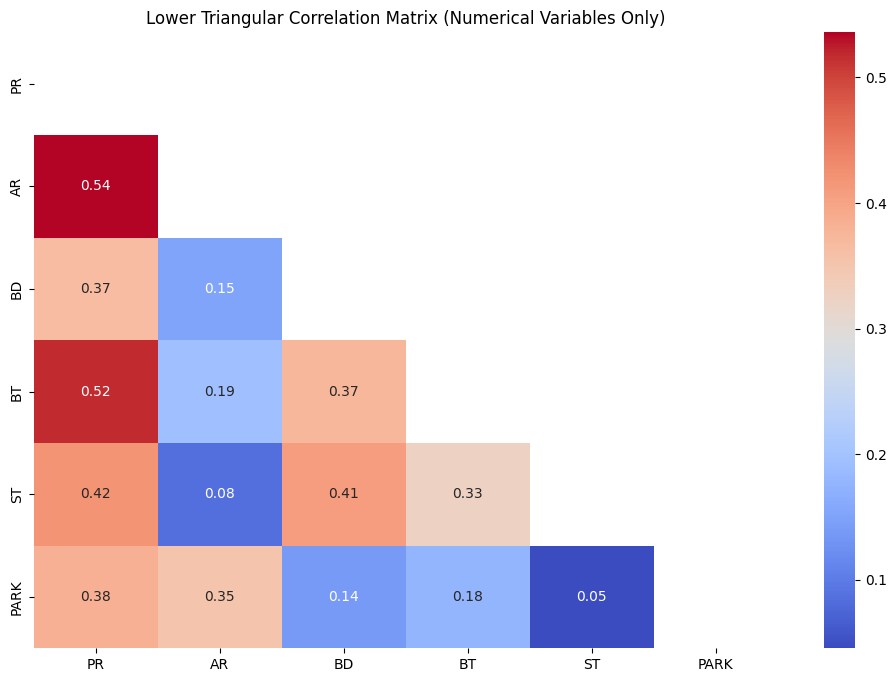

In [26]:
# 1. Select only numerical variables
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Compute correlation matrix
corr_matrix = numerical_df.corr()

# 3. Mask upper triangle (keep only lower triangular part)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
print(f'Correlations lower trangular matrix:\n{corr_matrix.mask(mask)}')

# 4. Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Lower Triangular Correlation Matrix (Numerical Variables Only)")
plt.show()


Correlation analysis highlights bathrooms and area as the strongest predictors of housing price. Bedrooms and parking provide moderate influence, while stories add value but capture distinct design choices. This guides feature selection: area, bathrooms, and stories should be prioritized in predictive modeling, while weaker correlations may be dropped to improve model efficiency.

#### Pairwise matrix Scatterplot

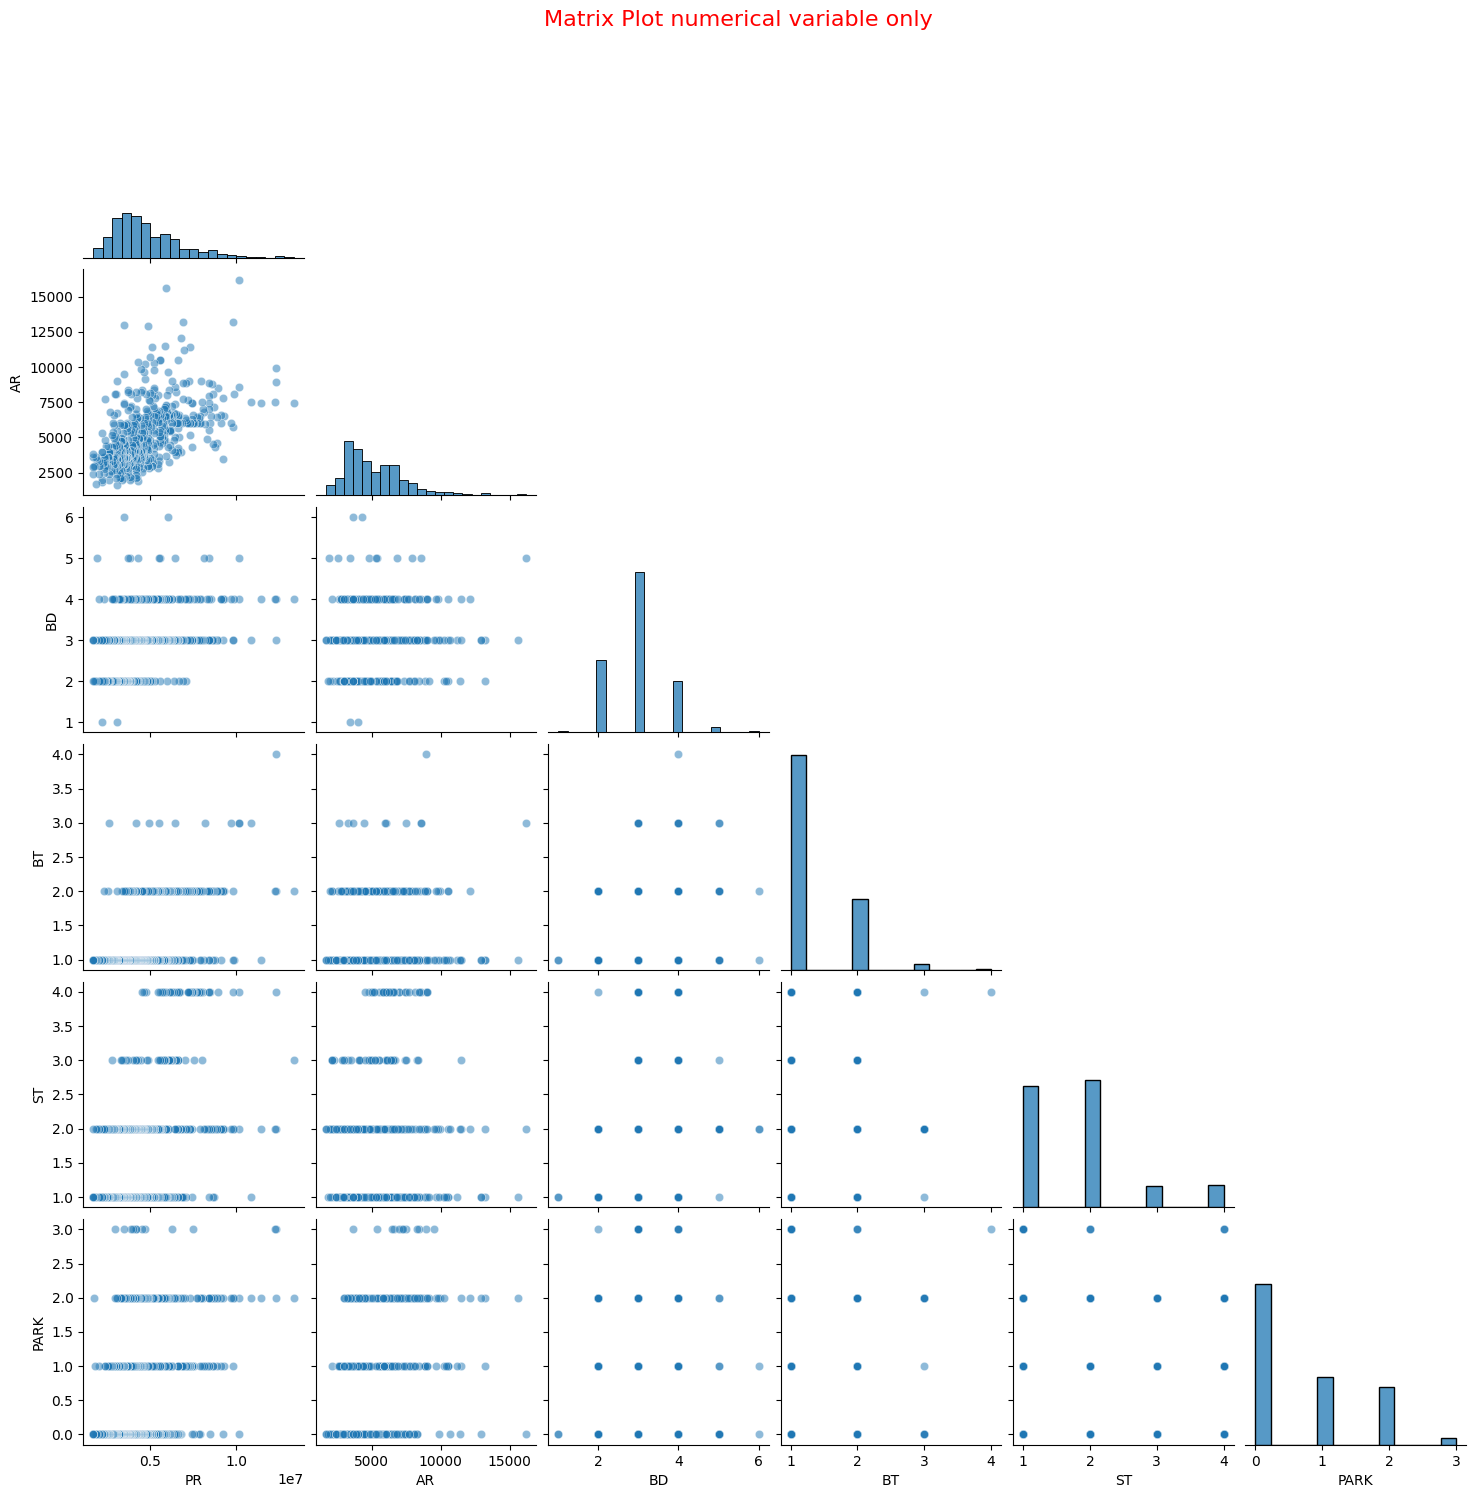

In [27]:
# 1. Select only numerical variables
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Pairwise scatterplots (pairplot)
sns.pairplot(numerical_df, diag_kind="hist", plot_kws={"alpha":0.5},corner=True)
plt.suptitle("Matrix Plot numerical variable only", y=1,fontsize=16,color='red')
plt.show()

- Strongest drivers of price: These variable play most significant role in housing price
    - area (0.536) → larger houses cost more.
    - bathrooms (0.518) → more bathrooms increase value.
    - stories (0.421) and parking (0.384) also contribute.
- Moderate correlations:
    - bedrooms with stories (0.409) and bathrooms (0.374).
    - price with bedrooms (0.366).
- Weak correlations:
    - stories with parking (0.046) → almost no relationship.
    - bedrooms with area (0.152).


Show the sorted correlation list alongside the heatmap. Highlight top predictors of price (area, bathrooms, stories, parking). Mention multicollinearity risks (e.g., bedrooms ↔ bathrooms ↔ stories).
Frame insights in business terms: “**Living area and bathroom count are the strongest drivers of housing prices.**”

Pair plot analysis confirms that area and bathrooms are the strongest predictors of housing price, while bedrooms, stories, and parking provide moderate influence. Distributions show skewness toward smaller, lower‑priced homes, with premium features concentrated in higher price ranges. This validates our feature selection strategy for predictive modeling.

#### Pairwise Contour Scatter Matrix Plot

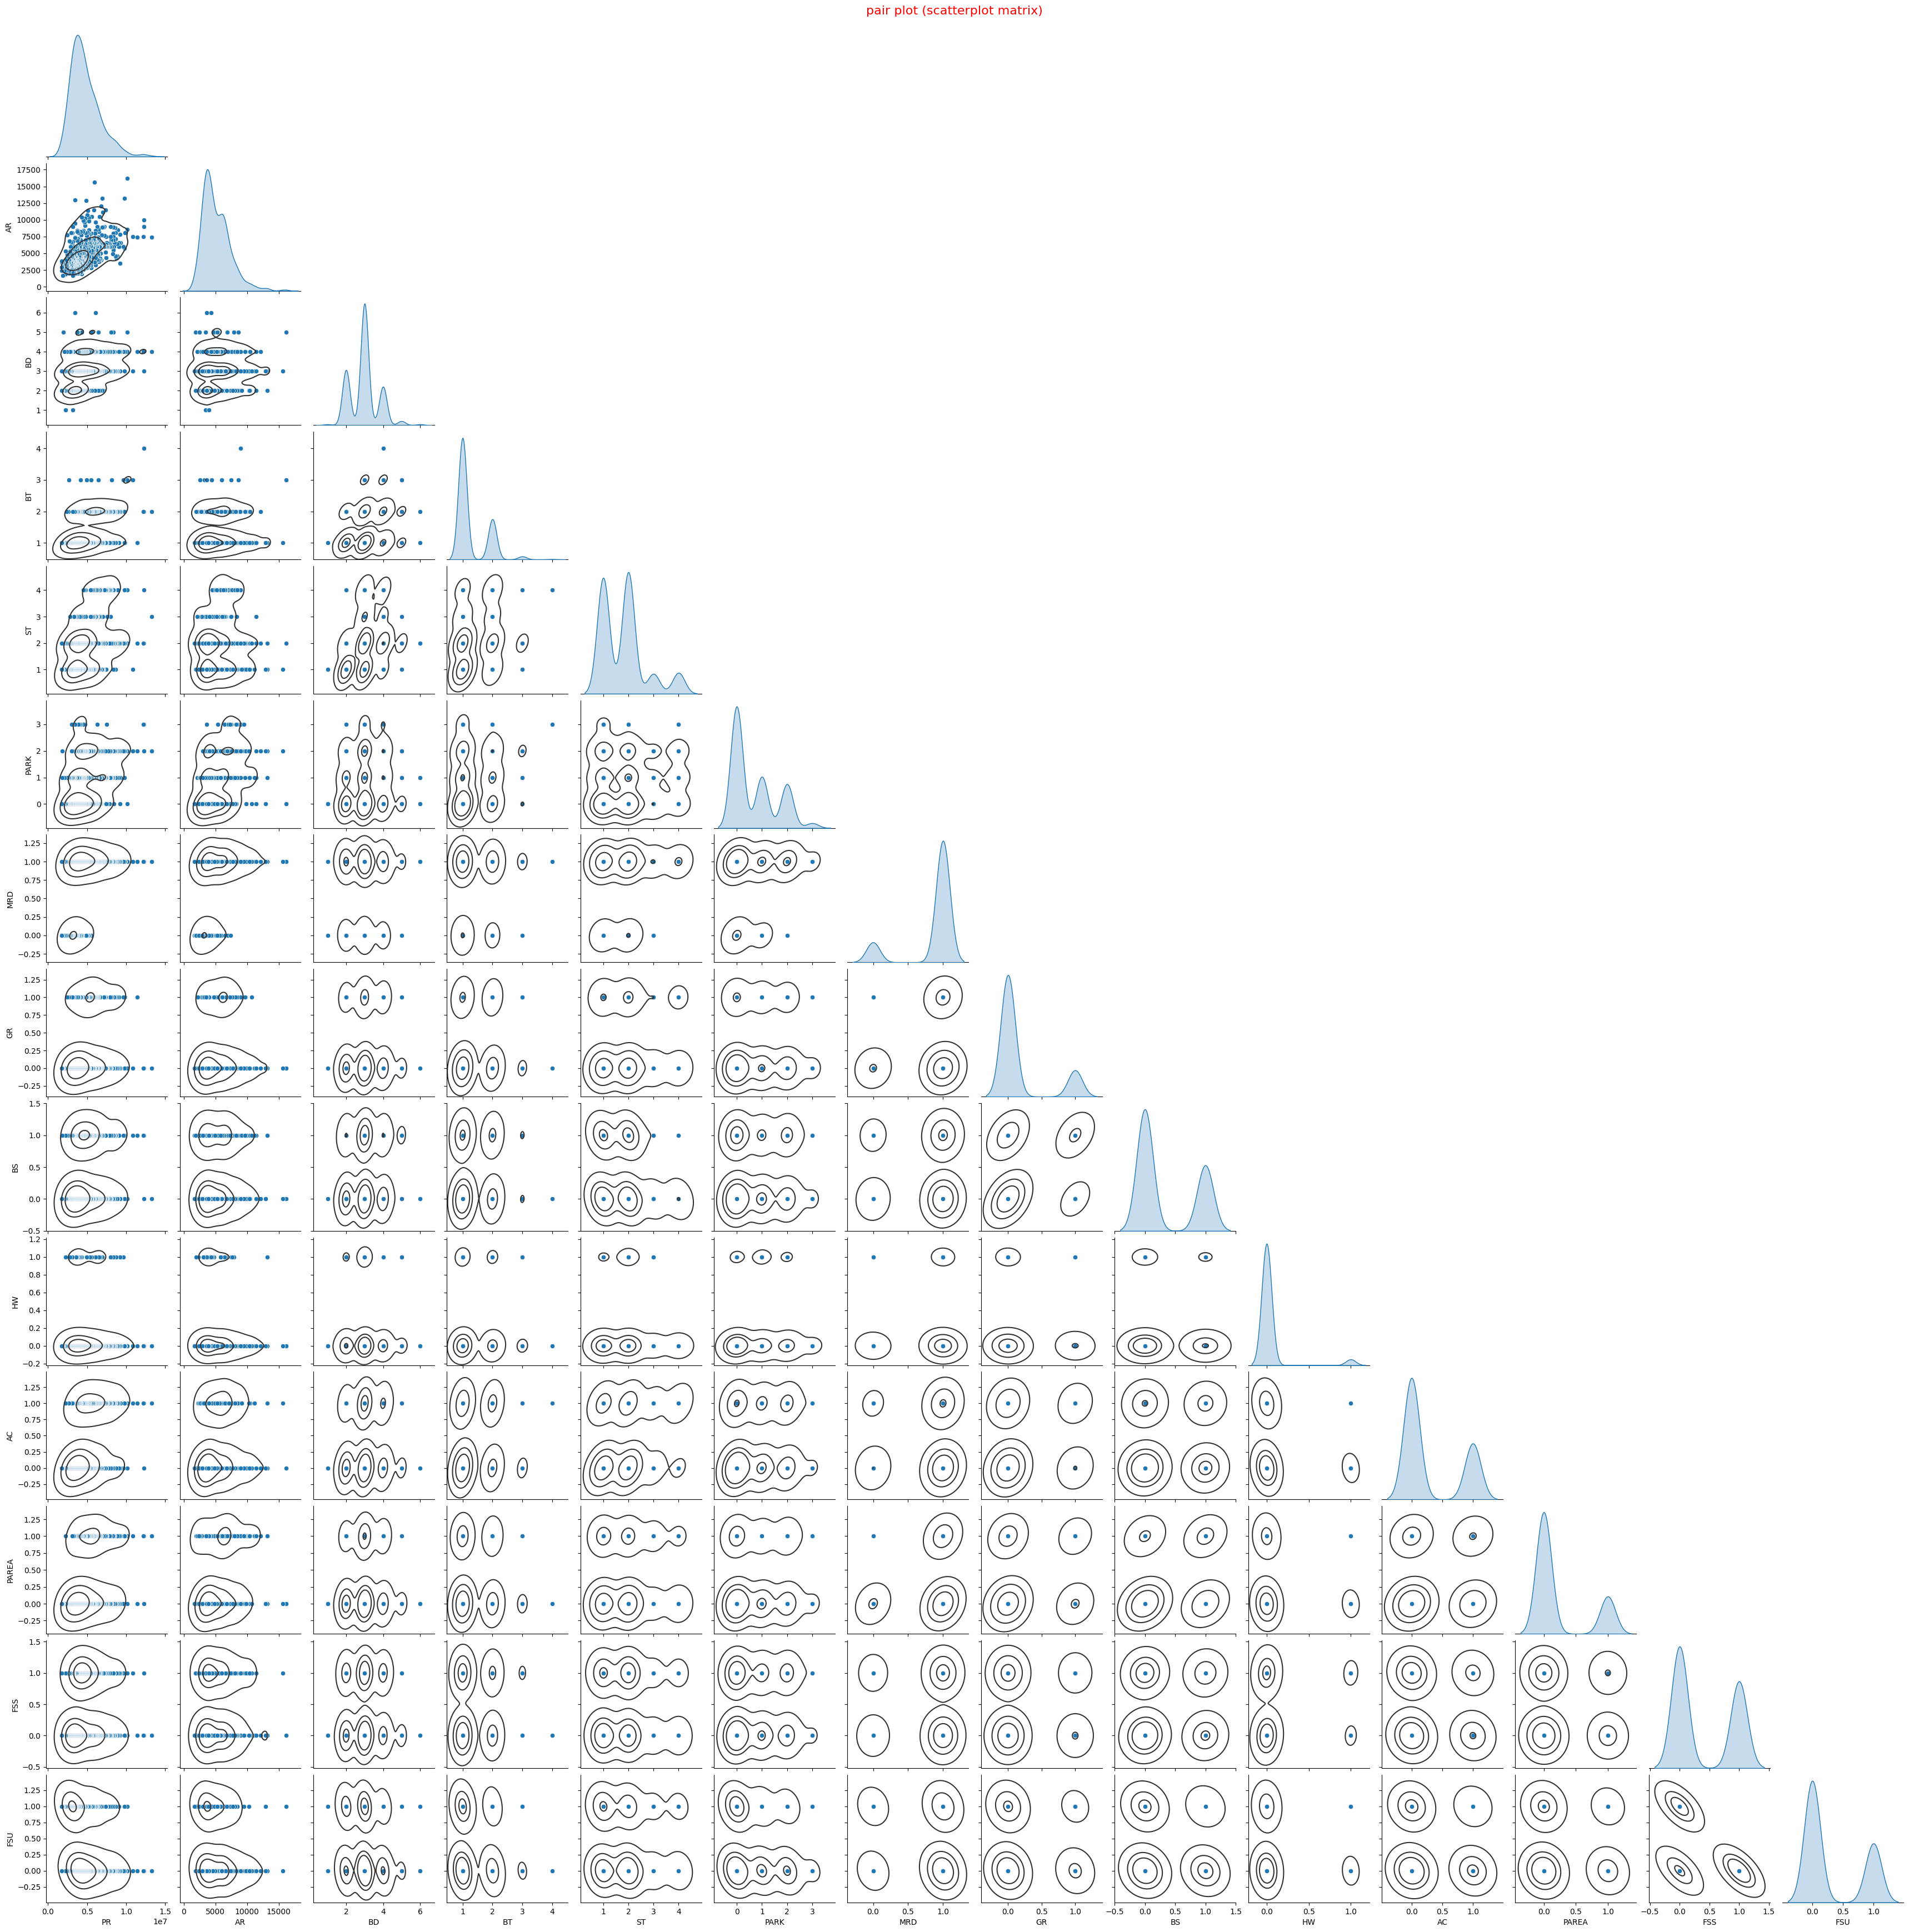

In [28]:
g = sns.pairplot(df, diag_kind="kde",corner=True)
g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.suptitle("pair plot (scatterplot matrix)", y=1,fontsize=16,color='red')
plt.show()

Pair plot analysis confirms that area and bathrooms are the strongest predictors of housing price, while bedrooms, stories, and parking provide moderate influence. Distributions highlight skewness toward smaller, lower‑priced homes, with premium features concentrated in higher price ranges. This validates our feature selection strategy for predictive modeling.

#### Calculations Variance Inflation Factor (VIF):

For predictor $X_j$, the VIF is defined as:

$C_{jj}=\frac{1}{1-R_j^2}$

$C_{jj}$ → diagonal element of the covariance matrix $(X'X)^{-1}$. $R_j^2$ → the coefficient of determination when regressing predictor $X_j$ on all other predictors.

So:

$VIF_j=C_{jj}=\frac{1}{1-R_j^2}$

where $R_j^2$ is the coefficient of determination when regressing $X_j$ on all the other predictors.

If $R_j^2$ is close to 1, it means predictor $X_j$ is highly explained by other predictors → strong multicollinearity. As $R_j^2\rightarrow 1$, the denominator $(1-R_j^2)$ becomes very small → $VIF_j$ becomes very large. A **large VIF indicates that the variance of the coefficient estimate for $X_j$ is inflated due to correlation with other predictors.**

VIF measures how much the variance of the estimated coefficient $\hat \beta_j$ is inflated due to multicollinearity


#### how multicollinearity is diagnosed and dealt with using VIF (Variance Inflation Factor) ?

#### Calculate  square root of the j‑th VIF

Qus: why we calculate square root of the j‑th VIF ?

Ans: The square root of the jth VIF indicates **how much longer the confidence interval** for the jth regression coefficient is because of multicollinearity. - The square root of the j‑th VIF gives the inflation factor of the standard error of $\hat {\beta }_j$.

$\sqrt{VIF_j}=\frac{\mathrm{SE\  with\  multicollinearity}}{\mathrm{SE\  without\  multicollinearity}}$

Please see another approch to understand the square root of the j‑th VIF

$\sqrt{VIF_j}=\sqrt{C_{jj}}=\frac{L_j}{L^*}$

Where:
- $VIF_j$ = Variance Inflation Factor for predictor $X_j$.
- $C_{jj}$ = diagonal element of the covariance matrix for coefficient $j$.
- $L_j$ = length of the confidence interval for coefficient $j$.
- $L^*$ = length of the confidence interval if predictors were orthogonal (uncorrelated)

#### length of Confidence Interval:

The confidence interval length for coefficient $j$ is:

$L_j=2\cdot \sqrt{C_{jj}\cdot \sigma ^2}\cdot t_{\alpha /2,n-p-1}$

In an orthogonal design (no multicollinearity), the interval length is:

$L^*=2\cdot \sigma \cdot t_{\alpha /2,n-p-1}$
- Therefore:
$\sqrt{VIF_j}=\frac{L_j}{L^*}$

$\sqrt{VIF_j}$ tells how much **longer the confidence interval for coefficient** $j$ is compared to the ideal case with no multicollinearity.

Take Example:
If $\sqrt{VIF_j}=2$, the confidence interval for $\beta _j$ is $twice$ as wide as it would be in an orthogonal design.

If $\sqrt{VIF_j}=5$, the interval is five times wider.

This directly links multicollinearity to loss of precision in estimating coefficients

#### Final conclusions:

Large $\sqrt{VIF_j}$ means your **coefficient estimates are unstable and less reliable**. Even if the predictor is theoretically important, high multicollinearity makes it hard to distinguish its unique effect. This is why **thresholds like VIF > 10 (or equivalently $\sqrt{VIF}>3.16$)** are **often used to flag problematic predictors**

- Interpretation:
    - VIF = 1–5 → Low correlation, safe.
    - VIF = 5–10 → Moderate correlation, caution.
    - VIF > 10 → High multicollinearity, problematic.

- Square root of VIF → tells you how much wider the confidence interval for $\hat \beta _j$ is compared to an orthogonal design (no correlation).



In [29]:
vif_data_single_sol = pd.DataFrame({})
vif_data_single_sol["feature"] = X_single_sol.columns
vif_data_single_sol["VIF"] = [variance_inflation_factor(X_single_sol.values, i) for i in range(X_single_sol.shape[1])]
# Add square root of VIF
vif_data_single_sol["sqrt_VIF"] = vif_data_single_sol["VIF"].apply(lambda x: x**0.5)
#print(vif_data_single_sol.to_string())
# Flag problematic predictors if sqrt_VIF > 3.16
vif_data_single_sol["problematic"] = vif_data_single_sol["sqrt_VIF"].apply(lambda x: "Yes" if x > 3.16 else "No")
print(vif_data_single_sol.to_string())


               feature         VIF   sqrt_VIF problematic
0            Intercept  297.170333  17.238629         Yes
1          MRD[T.True]   26.276753   5.126086         Yes
2           GR[T.True]   36.025356   6.002113         Yes
3           BS[T.True]   35.225179   5.935080         Yes
4           HW[T.True]   26.481041   5.145973         Yes
5           AC[T.True]   34.883770   5.906248         Yes
6        PAREA[T.True]   38.518192   6.206303         Yes
7          FSS[T.True]   38.603220   6.213149         Yes
8          FSU[T.True]   37.116202   6.092307         Yes
9                   AR   33.110858   5.754204         Yes
10      AR:MRD[T.True]   46.696494   6.833483         Yes
11       AR:GR[T.True]   19.576586   4.424544         Yes
12       AR:BS[T.True]   12.817908   3.580211         Yes
13       AR:HW[T.True]    8.082562   2.842985          No
14       AR:AC[T.True]   13.584424   3.685705         Yes
15    AR:PAREA[T.True]   13.118667   3.621970         Yes
16      AR:FSS

In [30]:
vif_data_two_line = pd.DataFrame()
vif_data_two_line["feature"] = X_two_line_sol.columns
vif_data_two_line["VIF"] = [variance_inflation_factor(X_two_line_sol.values, i) for i in range(X_two_line_sol.shape[1])]

# Add square root of VIF
vif_data_two_line["sqrt_VIF"] = vif_data_two_line["VIF"].apply(lambda x: x**0.5)

# Flag problematic predictors if sqrt_VIF > 3.16
vif_data_two_line["problematic"] = vif_data_two_line["sqrt_VIF"].apply(lambda x: "Yes" if x > 3.16 else "No")


print(vif_data_two_line.to_string())

          feature        VIF  sqrt_VIF problematic
0       Intercept  33.384521  5.777934         Yes
1     MRD[T.True]   1.172728  1.082926          No
2      GR[T.True]   1.212838  1.101289          No
3      BS[T.True]   1.323050  1.150239          No
4      HW[T.True]   1.041506  1.020542          No
5      AC[T.True]   1.211840  1.100836          No
6   PAREA[T.True]   1.149196  1.072006          No
7     FSS[T.True]   1.578233  1.256277          No
8     FSU[T.True]   1.674139  1.293885          No
9              AR   1.325250  1.151195          No
10             BD   1.369477  1.170246          No
11             BT   1.286621  1.134293          No
12             ST   1.478055  1.215753          No
13           PARK   1.212837  1.101289          No


#### Models 1 represent Single Line solutions and Models 2: represent Two line solutions. Explain the result.

Model 1: Single-Line Solutions (with interactions)
- Intercept VIF = 297 (√VIF ≈ 17.2) → Extremely inflated. This is a red flag: the model is overparameterized with too many overlapping predictors and interactions.
- Main categorical predictors (MRD, GR, BS, HW, AC, PAREA, FSS, FSU) → All have VIF between 26–39 (√VIF ≈ 5–6) → Severe multicollinearity.
- Numerical predictors (AR, BD, BT, ST, PARK) → VIF between 18–38 (√VIF ≈ 4–6). Again, very high.
- Interaction terms (e.g., AR:MRD, BD:GR, ST:MRD) → Many exceed VIF 40–50 (√VIF ≈ 6–7). This shows strong redundancy: interactions are highly correlated with their base variables.
- Some interactions are safe (e.g., AR:HW, ST:PAREA, PARK:GR) with VIF < 5, but the majority are problematic.

Model 1 suffers from severe multicollinearity. Almost every predictor and interaction inflates variance drastically. Confidence intervals for coefficients are 5–7× wider than they would be in an orthogonal design. Model 1 to be useful, regularization techniques (Ridge/Lasso) or feature selection are required to control variance inflation. Structural variables (area, bedrooms, bathrooms, stories, parking) are highly correlated, driving most of the multicollinearity. Categorical features (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus) are safe in the two-line model but problematic when combined with interactions.

Model 1 is flexible but suffers from redundancy due to overlapping predictors and interaction terms.

**Model 2 is simpler**, interpretable, and statistically sound, making it the preferred baseline model

#### Eigen vector and Conditional number:

#### Eigen vector how to address multi collinearity ?

Multicollinearity and Eigenvalues In regression, the correlation structure of predictors can be studied using the eigenvalues (characteristic roots) of the matrix X'X or the correlation matrix of predictors. Small eigenvalues (close to zero) indicate that some predictors are nearly linear combinations of others → this is multicollinearity. The smaller the eigenvalue, the stronger the dependency among predictors.


$\mathrm{Multicollinearity\  severity}\; \alpha \; \propto \frac{1}{\lambda }$\
$\lambda$  = eigenvalue of the predictor correlation matrix.

$\lambda$  is very small, then $\frac{1}{\lambda }$ becomes very large → strong multicollinearity.

#### Condition Number and Condition Indices in Eigenvalues:

When analyzing multicollinearity using eigenvalues of the predictor matrix $X'$X:

$\kappa =\frac{\lambda _{\mathrm{max}}}{\lambda _{\mathrm{min}}}$
- $\kappa$  = Condition Number
- $\lambda _{\mathrm{max}}$ = largest eigenvalue
- $\lambda _{\mathrm{min}}$ = smallest eigenvalue

#### Conditional Number analysis testing for Single line solutions

Remember that Singla line solutions contains 54 variable component

In [31]:
# Step 1: Compute correlation (or covariance) matrix
corr_matrix_single_sol = X_single_sol.drop(['Intercept'],axis='columns').corr()   # use .cov() for covariance matrix
# Step 3: Calculate eigenvalues_single_solutions and eigenvectors_single_solutions
eigenvalues_single_solutions, eigenvectors_single_solutions = np.linalg.eig(corr_matrix_single_sol)
print("eigenvalues_single_solutions from Singler Solutions:", np.round(eigenvalues_single_solutions,2))
#print("eigenvectors_single_solutions from Singler Solutions:\n", np.round(eigenvectors_single_solutions,3))
condition_number_single_solutions = max(eigenvalues_single_solutions) / min(eigenvalues_single_solutions)
if condition_number_single_solutions < 100:
    severity = "No serious multicollinearity"
elif 100 <= condition_number_single_solutions < 1000:
    severity = "Moderate to strong multicollinearity"
else:
    severity = "Severe multicollinearity"
tableDispFormatt('Condition Number')
print("Condition Number:", round(condition_number_single_solutions,6))
tableDispFormatt('Conditional Num analysis result')
print("Single Solutions Severity:", severity)

eigenvalues_single_solutions from Singler Solutions: [9.99 7.31 5.88 5.19 4.3  3.26 2.99 2.63 2.21 1.53 1.25 0.99 0.81 0.7
 0.55 0.39 0.33 0.29 0.24 0.21 0.18 0.15 0.14 0.13 0.12 0.11 0.1  0.09
 0.08 0.08 0.07 0.07 0.06 0.06 0.05 0.05 0.04 0.04 0.04 0.04 0.01 0.01
 0.01 0.01 0.01 0.02 0.02 0.02 0.03 0.03 0.02 0.03 0.03]
=============================== Condition Number ===========================================
Condition Number: 1302.253157
=============================== Conditional Num analysis result ============================
Single Solutions Severity: Severe multicollinearity


#### Conditional Number testing for Two line solutions:

Remember that Singla line solutions contains 14 variable component

In [32]:
# Step 1: Compute correlation (or covariance) matrix
corr_matrix_two_line_solutions = X_two_line_sol.drop(['Intercept'],axis='columns').corr()   # use .cov() for covariance matrix
# Step 3: Calculate eigenvalues_two_line_solutions and eigenvectors_two_line_solutions
eigenvalues_two_line_solutions, eigenvectors_two_line_solutions = np.linalg.eig(corr_matrix_two_line_solutions)
print("eigenvalues_two_line_solutions from Singler Solutions:", np.round(eigenvalues_two_line_solutions,2))
#print("eigenvectors_two_line_solutions from Singler Solutions:\n", np.round(eigenvectors_two_line_solutions,3))
condition_number_two_line_solutions = max(eigenvalues_two_line_solutions) / min(eigenvalues_two_line_solutions)
if condition_number_two_line_solutions < 100:
    severity = "No serious multicollinearity"
elif 100 <= condition_number_two_line_solutions < 1000:
    severity = "Moderate to strong multicollinearity"
else:
    severity = "Severe multicollinearity"    
tableDispFormatt('Condition Number')
print("Condition Number:", condition_number_two_line_solutions)
tableDispFormatt('Conditional Num analysis result')
print("Two Line Solutions Severity:", severity)

eigenvalues_two_line_solutions from Singler Solutions: [2.47 1.57 1.5  1.28 1.08 0.38 0.42 0.89 0.83 0.74 0.57 0.65 0.63]
=============================== Condition Number ===========================================
Condition Number: 6.533984339337997
=============================== Conditional Num analysis result ============================
Two Line Solutions Severity: No serious multicollinearity


#### 14.2.4. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) can be viewed as a powerful technique to **address multicollinearity** in a dataset.  
Instead of working directly with the original, often correlated variables, PCA transforms them into a new set of **uncorrelated variables** called *principal components*.  

- Each principal component is a **linear combination** of the original variables.  
- The components are ordered by importance:  
  - The **first principal component** captures the maximum possible variance in the data.  
  - Subsequent components explain progressively smaller amounts of variance, while remaining orthogonal (uncorrelated) to the previous ones.  

By using principal components as predictors in regression models, we reduce redundancy among variables, stabilize coefficient estimates, and improve interpretability.  
This makes PCA especially useful when dealing with datasets like Auto‑MPG, where variables such as displacement, horsepower, and weight are highly correlated.

While we won't dive into the formal mathematical derivations of PCA here, we will walk through the step-by-step implementation to understand how it transforms our correlated features into principal components.

Step 1: Find the variance–covariance matrix of dataset: for an example

The variance–covariance matrix of the data is:

$\Sigma =\left[ \begin{matrix}2.879368&10.01&-1.80905\\ 10.01&199.7884&-5.64\\ -1.80905&-5.64&3.627658\end{matrix}\right]$ 

Step 2:The eigenvalues and eigenvectors of this matrix, arranged in decreasing order of eigenvalues, are:

- $\lambda _1=200.462, with\ eigenvector\ a_1=(0.0508,0.9983,-0.0291)$
- $\lambda _2=4.532, with eigenvector a_2=(-0.5737,0.0530,0.8173)$
- $\lambda _3=1.301, with eigenvector a_3=(0.8175,-0.0249,0.5754)$

Step 3:The principal components are linear combinations of the original variables $x_1,x_2,x_3$:

$z_1=0.0508x_1+0.9983x_2-0.0291x_3$

$z_2=-0.5737x_1+0.0530x_2+0.8173x_3$

$z_3=0.8175x_1-0.0249x_2+0.5754x_3$

where $z_1,z_2,z_3$ are the principal component.

*Note: The variance of principal components will be eigenvalues*

The variance of the principal components is equal to the eigenvalues:

$\mathrm{Var}(z_1)=200.462,\quad \mathrm{Var}(z_2)=4.532,\quad \mathrm{Var}(z_3)=1.301$

The total variation explained by the principal components is:

$\lambda _1+\lambda _2+\lambda _3=200.462+4.532+1.301=206.295$

Step 4: Calculate proportion of total variation accounted for by the principal component

The proportion of total variation accounted for by the first principal component is

$\frac{\lambda _1}{\lambda _1+\lambda _2+\lambda _3}=\frac{200.462}{206.295}=0.9717\quad \mathrm{of\  the\  total\  variance}$

The proportion of total variance explained by the first two principal components is:

$\frac{\lambda _1+\lambda _2}{\lambda _1+\lambda _2+\lambda _3}=\frac{204.994}{206.295}=0.9937\quad \mathrm{of\  the\  total\  variance}$

Hence, in further analysis, the first one or two principal components ($Z_1$ and $Z_2$) can effectively replace the original three variables while sacrificing only a negligible amount of information about the total variation in the system. The loss of information is:
$1-0.9937=0.0063\approx 0.63\%$
This means that by excluding the third component, we retain over 99% of the variance. Such a reduction demonstrates the essence of dimensionality reduction: simplifying the dataset by removing redundant variables while preserving nearly all of the meaningful information.

Step 5: Finally calculate your PC component:

Let from your Dataset variables are

![alt text](image.png)

#### Feature Selection by Using PCA:

We applied multiple methods to calculate the principal components. Since our dataset contains many categorical variables, only the numerical features—specifically House Pricing and House Area—were included in the PCA. As a result, the analysis was limited to these two variables, and the outcomes were not highly satisfactory given the restricted scope of numerical data.

PCA is beneficial for reducing multicollinearity because it produces independent components, but it trades off interpretability. For categorical-heavy datasets, alternatives like Multiple Correspondence Analysis (MCA) or regularization methods (Ridge/Lasso regression) may be more suitable.


#### Method 1:

In [33]:
# Step by step PCA analysis
# return ProjectedData,PCA,PCA_variance,X_mean
def pca_step_by_step(X_centered, n_components):
    # Step 1: Standardize the data     
    # Standardize the data (mean=0, variance=1)        
    # Step 2: Compute the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)
    
    # Step 3: Compute the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Step 4: Sort the eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    # Step 5: Select the first n_components principle component eigenvectors
    PCs = sorted_eigenvectors[:, :n_components]*-1    
    # Step 6: Projected Data
    X_principal_component = np.dot(X_centered, PCs)
    # Step 7: Return the projected data, PCs, eigenvalues, and mean
    return X_principal_component, PCs, sorted_eigenvalues[:n_components]

Method 2: Numpy

In [34]:
# PCA by using numpy svd
def pca_from_svd(X_centered):
    # Step 1: Standardize the data
    print('pca_from_svd is set to True, standardizing the data')
       
    # Step 2: Perform Singular Value Decomposition (SVD)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    # U: left singular vectors
    # S: singular values
    # Vt: right singular vectors (principal component directions)
    # Step 3: Select the first n_components principal components
    # Eigenvalues from singular values
    eigenvalues = (S**2) / (X_centered.shape[0] - 1)
    # Explained variance ratio
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    Cumulative_variance      = np.cumsum(explained_variance_ratio)
    PCs = Vt.T
    # Transform data (scores);Project the data onto the principal components
    X_pca = np.dot(X_centered, PCs)
    
    return X_pca, PCs, explained_variance_ratio, Cumulative_variance

#### Method 3 
Scikit lern Library!

In [35]:
# Plot Explained variance as a function of the number of dimensions
def plot_explained_variance(explained_variance_ratio,Threshold,required_comp):
    """
    Plot the explained variance as a function of the number of dimensions.

    Parameters:
    pca (PCA object): Fitted PCA object.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(explained_variance_ratio) + 1), 
             np.cumsum(explained_variance_ratio), marker='o')    
    plt.title('Cumulative Explained Variance vs Number of Dimensions')
    plt.xlabel('Number of Dimensions')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid()
    plt.axhline(y=Threshold, color='r', linestyle='--', label='95% Threshold')
    plt.axvline(x=required_comp, color='red', linestyle='--', linewidth=2, label='Vertical Line')
    x_cross, y_cross = required_comp, Threshold
    plt.annotate(f"({x_cross}, {y_cross:.2f})",
             xy=(x_cross, y_cross),
             xytext=(x_cross+8, y_cross-0.1),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='purple')

    plt.legend()
    plt.show()


#### PCA is Highly Affected by Scaling:

Principal Component Analysis (PCA) finds directions (principal components) that maximize variance in the data. Features with larger numerical ranges naturally have higher variance. If one feature has values in the thousands and another in decimals, the large-scale feature dominates the variance, skewing PCA results.

PCA is based on the covariance matrix (or correlation matrix if standardized). Covariance depends on the units and scale of variables. Without scaling, features measured in larger units contribute disproportionately to covariance, biasing the principal components.

PCA essentially rotates the coordinate system to align with directions of maximum spread. If features are on different scales, the "spread" is distorted—like stretching one axis more than the other. This makes PCA capture scale differences rather than true structure in the data



In [36]:
# PCA sensitive for scaled dataset. So first we scaled data
standard_scaler = StandardScaler()
min_max_scaler  = MinMaxScaler(feature_range=(0,1))


=============================== Variance Testing ===========================================
Is total sum of Principal component variance is same as the diagonal sum of covariance matrix ?

Total variance contribute by Principal component 53.097
Total variance contribute by covariance matrix   53.097
Yes They are equals!!!!
=============================== Variance Testing end =======================================
[np.float64(0.188517), np.float64(0.137921), np.float64(0.110855), np.float64(0.097999), np.float64(0.081154), np.float64(0.061485), np.float64(0.056324), np.float64(0.049633), np.float64(0.04165), np.float64(0.028887), np.float64(0.023673), np.float64(0.018765), np.float64(0.015301), np.float64(0.013209), np.float64(0.010341), np.float64(0.007308), np.float64(0.006255), np.float64(0.005423), np.float64(0.004483), np.float64(0.004004), np.float64(0.003468), np.float64(0.00286), np.float64(0.002712), np.float64(0.002494), np.float64(0.002243), np.float64(0.002063), np.float64

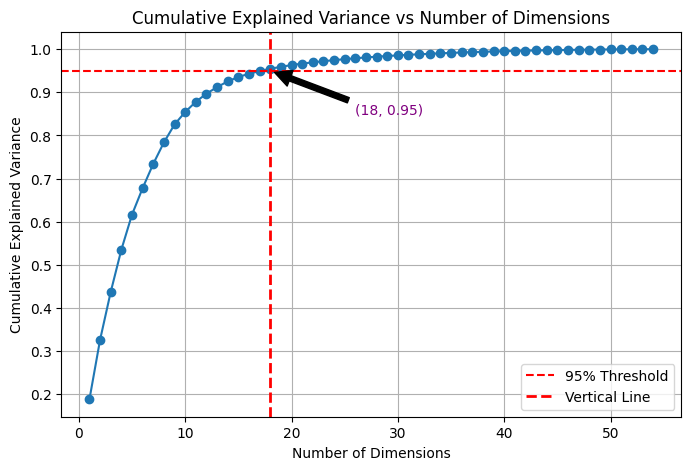

In [37]:
n_samples,n_features = X_single_sol.shape[0],X_single_sol.shape[1]
scaled_data_single_line_sol = standard_scaler.fit_transform(X_single_sol)

X_PCA_Single_Line_Sol, PCs_Single_Line_Sol, Eigen_Single_line_Sol = \
                       pca_step_by_step(scaled_data_single_line_sol,min(n_samples, n_features))

tableDispFormatt('Variance Testing')
print('Is total sum of Principal component variance is same as the diagonal sum of covariance matrix ?\n')
print(f'Total variance contribute by Principal component {np.round(np.sum(Eigen_Single_line_Sol),3)}')
covariance_matrix_scaled = np.cov(scaled_data_single_line_sol, rowvar=False)
print(f'Total variance contribute by covariance matrix   {np.round(np.sum(np.diag(covariance_matrix_scaled)),3)}')
if np.round(np.sum(Eigen_Single_line_Sol),3) == np.round(np.sum(np.diag(covariance_matrix_scaled)),3):
    print(f'Yes They are equals!!!!')
else:
    print('They are not equal')
tableDispFormatt('Variance Testing end')

sum_variance = np.sum(Eigen_Single_line_Sol)
proportions = []
for i, egn in enumerate(Eigen_Single_line_Sol):
    proportions.append(egn / sum_variance)
# Round each element in the proportions list to 3 decimal places
proportions = [round(p, 6) for p in proportions]
print(proportions)
keep_dimensions = choose_number_of_dimensions(proportions, threshold=0.95)
print(f'Number of dimensions to keep with only 5% info loss ==> {keep_dimensions} out of {len(proportions)} variable')
plot_explained_variance(proportions, Threshold=0.95, required_comp=choose_number_of_dimensions(proportions, threshold=0.95))

pca_from_svd is set to True, standardizing the data
=============================== Variance Testing ===========================================
Is total sum of Principal component variance is same as the diagonal sum of covariance matrix ?

Total variance contribute by Principal component 1.0
Total variance contribute by covariance matrix   53.097
They are not equal
=============================== Variance Testing end =======================================
[np.float64(0.188517), np.float64(0.137921), np.float64(0.110855), np.float64(0.097999), np.float64(0.081154), np.float64(0.061485), np.float64(0.056324), np.float64(0.049633), np.float64(0.04165), np.float64(0.028887), np.float64(0.023673), np.float64(0.018765), np.float64(0.015301), np.float64(0.013209), np.float64(0.010341), np.float64(0.007308), np.float64(0.006255), np.float64(0.005423), np.float64(0.004483), np.float64(0.004004), np.float64(0.003468), np.float64(0.00286), np.float64(0.002712), np.float64(0.002494), np.float64

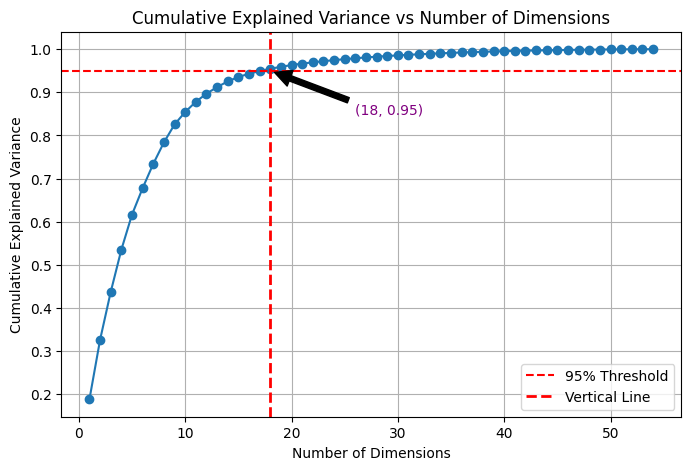

In [38]:
n_samples,n_features = X_single_sol.shape[0],X_single_sol.shape[1]
scaled_data_single_line_sol = standard_scaler.fit_transform(X_single_sol)

X_PCA_Single_Line_Sol, PCs_Single_Line_Sol, Eigen_Single_line_Sol, X_mean = \
                       pca_from_svd(scaled_data_single_line_sol)

tableDispFormatt('Variance Testing')
print('Is total sum of Principal component variance is same as the diagonal sum of covariance matrix ?\n')
print(f'Total variance contribute by Principal component {np.round(np.sum(Eigen_Single_line_Sol),3)}')
covariance_matrix_scaled = np.cov(scaled_data_single_line_sol, rowvar=False)
print(f'Total variance contribute by covariance matrix   {np.round(np.sum(np.diag(covariance_matrix_scaled)),3)}')
if np.round(np.sum(Eigen_Single_line_Sol),3) == np.round(np.sum(np.diag(covariance_matrix_scaled)),3):
    print(f'Yes They are equals!!!!')
else:
    print('They are not equal')
tableDispFormatt('Variance Testing end')

sum_variance = np.sum(Eigen_Single_line_Sol)
proportions = []
for i, egn in enumerate(Eigen_Single_line_Sol):
    proportions.append(egn / sum_variance)
# Round each element in the proportions list to 3 decimal places
proportions = [round(p, 6) for p in proportions]
print(proportions)

keep_dimensions = choose_number_of_dimensions(proportions, threshold=0.95)
print(f'Number of dimensions to keep with only 5% info loss ==> {keep_dimensions} out of {len(proportions)} variable')

plot_explained_variance(proportions, Threshold=0.95, required_comp=choose_number_of_dimensions(proportions, threshold=0.95))

In [39]:

numeric_cols = X_single_sol.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_single_sol.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), numeric_cols),
    ('encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


In [40]:
def PrincipalComponentAnalysis(X_DataFrame):
    numeric_cols = X_DataFrame.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = X_DataFrame.select_dtypes(include=['object']).columns
    preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), numeric_cols),
    ('encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])
    X_processed = preprocessor.fit_transform(X_DataFrame)
    
    # Apply PCA
    n_samples,n_features   = X_DataFrame.shape[0],X_DataFrame.shape[1]
    pca = PCA(n_components = min(n_samples, n_features)) # choose number of components
    X_pca = pca.fit_transform(X_processed)
    explained_variance_ratio = pca.explained_variance_ratio_
    PCs = pca.components_
    feature_names = preprocessor.get_feature_names_out()
    #print(feature_names)
    return X_pca,PCs,explained_variance_ratio,feature_names  



=============================== Variance Testing ===========================================
Is total sum of Principal component variance is same as the diagonal sum of covariance matrix ?

Total variance contribute by Principal component 1.0
Total variance contribute by covariance matrix   53.097
They are not equal
=============================== Variance Testing end =======================================
[np.float64(0.188517), np.float64(0.137921), np.float64(0.110855), np.float64(0.097999), np.float64(0.081154), np.float64(0.061485), np.float64(0.056324), np.float64(0.049633), np.float64(0.04165), np.float64(0.028887), np.float64(0.023673), np.float64(0.018765), np.float64(0.015301), np.float64(0.013209), np.float64(0.010341), np.float64(0.007308), np.float64(0.006255), np.float64(0.005423), np.float64(0.004483), np.float64(0.004004), np.float64(0.003468), np.float64(0.00286), np.float64(0.002712), np.float64(0.002494), np.float64(0.002243), np.float64(0.002063), np.float64(0.00196

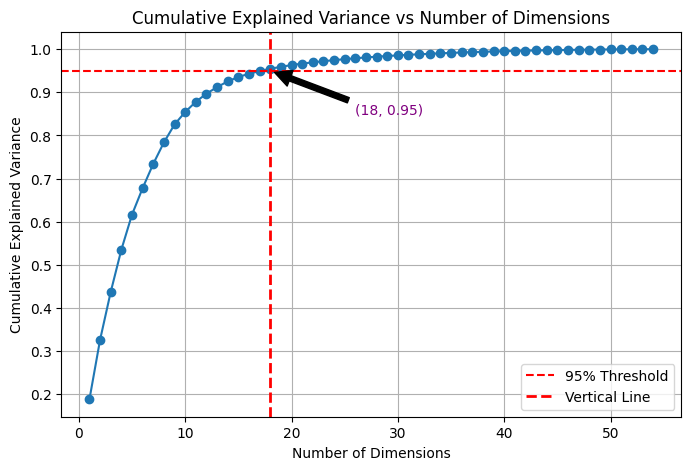

In [41]:
X_PCA_Single_Line_Sol,PCs_Single_Line_Sol,Eigen_Single_line_Sol,feature_names__ = \
PrincipalComponentAnalysis(X_single_sol)

tableDispFormatt('Variance Testing')
print('Is total sum of Principal component variance is same as the diagonal sum of covariance matrix ?\n')
print(f'Total variance contribute by Principal component {np.round(np.sum(Eigen_Single_line_Sol),3)}')
covariance_matrix_scaled = np.cov(scaled_data_single_line_sol, rowvar=False)
print(f'Total variance contribute by covariance matrix   {np.round(np.sum(np.diag(covariance_matrix_scaled)),3)}')
if np.round(np.sum(Eigen_Single_line_Sol),3) == np.round(np.sum(np.diag(covariance_matrix_scaled)),3):
    print(f'Yes They are equals!!!!')
else:
    print('They are not equal')
tableDispFormatt('Variance Testing end')

sum_variance = np.sum(Eigen_Single_line_Sol)
proportions = []
for i, egn in enumerate(Eigen_Single_line_Sol):
    proportions.append(egn / sum_variance)
# Round each element in the proportions list to 3 decimal places
proportions = [round(p, 6) for p in proportions]
print(proportions)

keep_dimensions = choose_number_of_dimensions(proportions, threshold=0.95)
print(f'Number of dimensions to keep with only 5% info loss ==> {keep_dimensions} out of {len(proportions)} variable')

# Sum of first choose_number_of_dimensions() components
sum_first_choosen_components = np.sum(proportions[:choose_number_of_dimensions(proportions, threshold=0.95)])

print("Sum of first choosen components:", sum_first_choosen_components)

plot_explained_variance(proportions, Threshold=0.95, required_comp=choose_number_of_dimensions(proportions, threshold=0.95))

Instead of using all 55+ original features, we can reduce the dataset to 18 components while still preserving almost all the information. This makes models faster, reduces multicollinearity, and avoids overfitting. However, **PCA components are linear combinations of the original variables,** so they don’t directly tell you which raw features are most important — further analysis (like hypothesis testing, Lasso regression, or feature importance checks) is needed.


#### PCA component analysis for two line solutions models

=============================== Variance Testing ===========================================
Is total sum of Principal component variance is same as the diagonal sum of covariance matrix ?

Total variance contribute by Principal component 1.0
Total variance contribute by covariance matrix   53.097
They are not equal
=============================== Variance Testing end =======================================
[np.float64(0.189974), np.float64(0.120988), np.float64(0.11539), np.float64(0.098144), np.float64(0.083429), np.float64(0.068411), np.float64(0.063595), np.float64(0.056765), np.float64(0.049983), np.float64(0.048224), np.float64(0.044092), np.float64(0.03193), np.float64(0.029075), np.float64(0.0)]
Number of dimensions to keep with only 5% info loss ==> 12 out of 14 variable
Sum of first choosen components: 0.9709250000000001


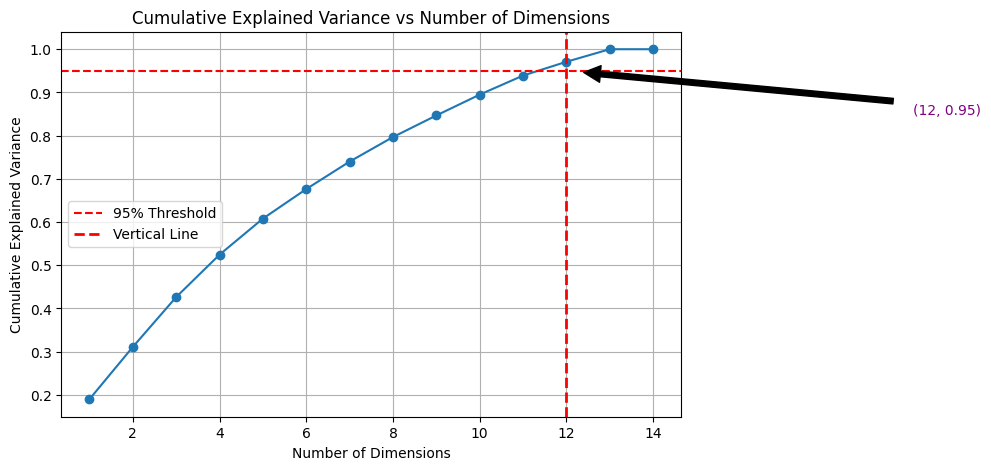

In [42]:
X_PCA_Two_Line_Sol,PCs_Two_Line_Sol,Eigen_Two_line_Sol,feature_names__ = \
PrincipalComponentAnalysis(X_two_line_sol)

tableDispFormatt('Variance Testing')
print('Is total sum of Principal component variance is same as the diagonal sum of covariance matrix ?\n')
print(f'Total variance contribute by Principal component {np.round(np.sum(Eigen_Two_line_Sol),3)}')
covariance_matrix_scaled = np.cov(scaled_data_single_line_sol, rowvar=False)
print(f'Total variance contribute by covariance matrix   {np.round(np.sum(np.diag(covariance_matrix_scaled)),3)}')
if np.round(np.sum(Eigen_Two_line_Sol),3) == np.round(np.sum(np.diag(covariance_matrix_scaled)),3):
    print(f'Yes They are equals!!!!')
else:
    print('They are not equal')
tableDispFormatt('Variance Testing end')

sum_variance = np.sum(Eigen_Two_line_Sol)
proportions = []
for i, egn in enumerate(Eigen_Two_line_Sol):
    proportions.append(egn / sum_variance)
# Round each element in the proportions list to 3 decimal places
proportions = [round(p, 6) for p in proportions]
print(proportions)

keep_dimensions = choose_number_of_dimensions(proportions, threshold=0.95)
print(f'Number of dimensions to keep with only 5% info loss ==> {keep_dimensions} out of {len(proportions)} variable')

# Sum of first choose_number_of_dimensions() components
sum_first_choosen_components = np.sum(proportions[:choose_number_of_dimensions(proportions, threshold=0.95)])

print("Sum of first choosen components:", sum_first_choosen_components)

plot_explained_variance(proportions, Threshold=0.95, required_comp=choose_number_of_dimensions(proportions, threshold=0.95))

#### PCA Component Result Analysis:

I applied Principal Component Analysis (PCA) to the Kaggle Housing Prices dataset to explore dimensionality reduction and multicollinearity management. Since PCA is valid only for numerical regressors, categorical features were excluded or encoded separately.

Before starting, it is important to note that PCA results are valid only for numerical **regressor variables**. If the dataset contains categorical components, the PCA outcomes may not be fully reliable, since PCA is not designed to handle categorical data directly.

Another limitation of **PCA** is that it does not explicitly indicate which variables should be removed from the dataset. In our analysis, we observed that **95% of the variance in the dataset is explained by only 18 components**, allowing us to discard the remaining components. However, PCA does not guarantee that all of these 18 retained components correspond to variables that are truly significant compared to those discarded. Therefore, further investigation is required.

#### PCA and Variance Inflation Factor (VIF)

One clear advantage of PCA is its ability to reduce **multicollinearity**. As we know, VIF increases when more correlated variables are added to a model. By applying PCA, variability is compressed into fewer orthogonal components, which in turn reduces the overall VIF of the regressors.

#### Next Steps:

To strengthen the analysis and validate the findings, we need to perform additional investigations, such as:
- **Hypothesis testing** to assess the statistical significance of regressor variables.
- **Lasso regression & ridge regressions** for feature selection, which can help identify the most impactful predictors.
- Model comparison between the full dataset and the reduced PCA components, followed by validation of results to ensure robustness.

#### What's should be happen compute VIF for PCA components? Also explain what should be the expected result?

 PCA Components creates orthogonal (uncorrelated) components by construction. Each principal component is a linear combination of the original variables, but the components themselves are mutually independent in terms of correlation. But because PCA components are orthogonal, the correlation between them is zero (or extremely close to zero, up to numerical precision).

**The VIF for PCA components will be ≈ 1 for all components.**

Why? Because $VIF = \frac{1}{1-R^2}$, 

where $R_j^2$ is the $R^2$ from regressing predictor j on all the other predictors. and if predictors are uncorrelated, $R_j^2=0$ from regressing one component on the others is ~0. So, $VIF\approx 1$ → no multicollinearity.


In [43]:
# write code to clasculate VIF first 18 component from X_PCA_Single_Line_Sol
# Calculate VIF for the first 18 components
num_components = choose_number_of_dimensions(proportions, threshold=0.95)
vif_data_pca = pd.DataFrame({})
vif_data_pca["feature"] = [f'PC{i+1}' for i in range(num_components)]
vif_data_pca["VIF"] = [variance_inflation_factor(X_PCA_Single_Line_Sol[:, :num_components], i) for i in range(num_components)]
print(vif_data_pca.to_string())

   feature  VIF
0      PC1  1.0
1      PC2  1.0
2      PC3  1.0
3      PC4  1.0
4      PC5  1.0
5      PC6  1.0
6      PC7  1.0
7      PC8  1.0
8      PC9  1.0
9     PC10  1.0
10    PC11  1.0
11    PC12  1.0


#### Feature Selections L1 regularizations (Lasso)

#### What is L1 Regularization (Lasso)?

Regularization means adding a penalty term to the loss function to prevent overfitting. In L1 regularization (Lasso), the penalty is the sum of the absolute values of the coefficients


#### Formula for Lasso regression (L1 regularization):

$\sum _{i=1}^n\left( Y_i-\sum _{j=1}^pX_{ij}\beta _j\right) ^2+\lambda \sum _{j=1}^p|\beta _j|$

$OLS loss = \sum _{i=1}^n\left( Y_i-\sum _{j=1}^pX_{ij}\beta _j\right) ^2$

This is the residual sum of squares (RSS). It measures how far the predicted values are from the actual target values. Minimizing this alone gives you ordinary least squares (OLS) regression.

$L1 Penalty = \lambda \sum _{j=1}^p|\beta _j|$

This is the regularization term. It penalizes large coefficients by adding their absolute values to the loss. $\lambda$  controls the strength of the penalty:
- If $\lambda =0$: no penalty → standard OLS.
- If $\lambda$  is small: coefficients shrink slightly.
- If $\lambda$  is large: many coefficients are forced to **exactly zero → feature selection**

#### Why "Penalizes High-Value Coefficients"?

The term $\lambda \sum |\beta _j|$ adds cost whenever coefficients grow large. If a coefficient $\beta _j$ is big, the penalty increases → the optimizer prefers smaller values. This forces the model to shrink coefficients toward zero

#### Feature Selection:

Because the penalty uses absolute values, the optimization **geometry has sharp corners (diamond-shaped constraint)**. At those corners, many coefficients are forced to be exactly zero. This means Lasso doesn’t just shrink coefficients — it can eliminate features entirely. That’s why Lasso is both a regularization method and a feature selection method. With L1 regularization, only the most important features survive; irrelevant ones are set to zero. With stronger $\lambda$, more coefficients are zero → fewer features selected

L1 regularization (Lasso) adds a penalty proportional to the absolute size of coefficients. This discourages large values, shrinks them toward zero, and often sets some coefficients exactly to zero, effectively performing automatic feature selection.

*Detailed explanations of Lasso (L1 regularization) are beyond the scope of this notebook. Our focus is limited to feature selection and identifying statistically significant regression variables using L1 regularization.*

#### formulas for regression sums of squares and mean squares

1. Residual Sum of Squares ($SS{}_{res}$) Measures unexplained variation (errors).

    $SS_{res}=\sum _{i=1}^n(y_i-\hat {y}_i)^2$

    - Always ≥ 0 (since it’s a sum of squared errors).
    - Smaller values → better fit (predictions close to actuals).
    - Larger values → poor fit (model leaves more unexplained variation)

2. Mean Square of Residuals ($MS{}_{res}$): Average unexplained variation per degree of freedom.

    $MS_{res}=\frac{SS_{res}}{n-p-1}$

    - Represents the average unexplained variance per degree of freedom.
    - Should be relatively small if the model fits well.
    - Used as the denominator in the F‑test.


3. Regression Sum of Squares ($SS{}_{reg}$):Measures explained variation by the model

    $SS_{reg}=\sum _{i=1}^n(\hat {y}_i-\bar {y})^2$

    - Always ≥ 0.
    - Larger values → model explains more variation in the data.
    - If $SS_{reg}$ is close to $SS_{tot}$, the model explains almost all variability.


4. Mean Square of Regression ($MS{}_{reg}$): Average explained variation per predictor.

    $MS_{reg}=\frac{SS_{reg}}{p}$

    - Represents the average explained variance per predictor.
    - Larger values → predictors are collectively strong.
    - Used as the numerator in the $F‑test$.

5. Total Sum of Squares ($SS{}_{tot}$): Overall variation in the data

    $SS_{tot}=\sum _{i=1}^n(y_i-\bar {y})^2$

    And the decomposition holds:

    $SS_{tot}=SS_{reg}+SS_{res}$

    - F‑statistic:
    $F=\frac{MS_{reg}}{MS_{res}}$
    - If F is large → regression model is statistically significant.
    - If F is close to 1 → model doesn’t explain much beyond random noise.

6. Adjusted R² accounts for the number of predictors p and sample size n:

    $R_{adj}^2=1-\left( \frac{(1-R^2)(n-1)}{n-p-1}\right)$ 
    - $R^2$ = coefficient of determination
    - n = number of observations
    - p = number of predictors (features used in the model)
    - Adjusted R² will always be ≤ R². It penalizes adding irrelevant predictors


#### Qus: why Scaling technique applied on Regressor/Independent Variable not on the Dependent Variable?

Scaling is applied to independent variables (regressors) because it improves optimization, convergence, and comparability of features. The dependent variable (target) is not scaled because its scale carries the actual meaning of the prediction — changing it would distort the output values.

The target variable represents the actual quantity we want to predict (e.g., house price, temperature). Scaling it would make predictions meaningless unless we rescale back.

**Regression coefficients adjust automatically**: Linear regression inherently adjusts coefficients to match the target’s scale. Scaling the target adds no benefit. Metrics like RMSE, MAE, or R² are meaningful only in the target’s natural units. Scaling would distort these measures.

#### Preparing the Dataset for Lasso Regression:
 
- Step 1: Load the Housing dataset.
- Step 2: Apply one‑hot encoding to categorical variables to convert them into numerical indicator variables.
- Step 3: Apply scaling to the independent variables to ensure all features contribute proportionally during model training.

Model Formulations
We evaluate two different model setups:

#### Two Line Solutions:

Uses a simplified formula with indicator variables represented in a single line. Focuses on direct feature selection and interpretable coefficients.Easier to interpret, highlights the most impactful predictors, and demonstrates how Lasso shrinks irrelevant features to zero.

#### Single Line Solution

Uses a more complex formula with interaction terms or multiple indicator lines. Captures relationships between variables that may not be visible in the single line setup. Provides a broader view of feature interactions, though it may introduce redundancy or weaker explanatory power compared to the single line approach.


By comparing both, we can see how Lasso balances simplicity vs complexity, and identify which formulation yields better generalization, lower residual error, and stronger explanatory power.


#### Lasso Regressions Feature Selections:

In [44]:
standard_scaler = StandardScaler()
min_max_scaler  = MinMaxScaler(feature_range=(0,1))

X_scaled_std_scal_single_line = standard_scaler.fit_transform(X_single_sol)
X_scaled_min_max_scal_single_line = min_max_scaler.fit_transform(X_single_sol)

X_scaled_std_scal_two_line = standard_scaler.fit_transform(X_two_line_sol)
X_scaled_min_max_scal_two_line = min_max_scaler.fit_transform(X_two_line_sol)

In [45]:
# Define alpha values
alphas = [0.01, 0.1, 10, 50, 100,150,200,250,300,500,1000]
single_line_sol_dist = {}
def Lasso_regressions_feature_selections(X_scaled_data,y__,independent_variable_,alphas):
	# Run Lasso for each alpha
	results_selected_feature = {}
	results_rejected_feature = {}
	state_results = []
	y_var = y__.to_numpy().reshape(-1,1)
	n_sample_ =  independent_variable_.shape[0]
	for alpha in alphas:
		lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
		lasso.fit(X_scaled_data, y__)
		
		coef = pd.Series(lasso.coef_, index=independent_variable_.columns)
		
		# Selected (non-zero coefficients)
		selected_features = coef[coef != 0].index.tolist()
		
		# Rejected (zero coefficients)
		rejected_features = coef[coef == 0].index.tolist()
		results_selected_feature[alpha] = selected_features
		results_rejected_feature[alpha] = rejected_features
		
		tableDispFormatt('result Analysis: '+ f'{alpha}')
		print(f"\nAlpha = {alpha}")
		print("Selected Features:", selected_features)
		print("Rejected Features:", rejected_features)
		print(f'totals feature selected: {len(selected_features)} out of {independent_variable_.shape[1]} feature')
		print(f'totals feature rejected: {len(rejected_features)} out of {independent_variable_.shape[1]} feature')

		# Predictions and residuals
		y_pred = lasso.predict(X_scaled_data)		
		residuals = y_var - y_pred
		# R-squared
		ss_res = np.sum(residuals**2)
		ss_tot = np.sum((y_var - np.mean(y_var))**2)
		r2 = 1 - ss_res/ss_tot
		# Degrees of freedom
		df_model = np.sum(lasso.coef_ != 0)
		df_resid = n_sample_ - df_model - 1
		# Adjusted R-squared
		adj_r2 = 1 - (1-r2)*(n_sample_-1)/(df_resid) if df_resid > 0 else np.nan
        # MSres (Residual Mean Square Error)
		ms_res = ss_res / df_resid if df_resid > 0 else np.nan
		# MSr (Mean Square Regression)
		ss_reg = np.sum((y_pred - np.mean(y_var))**2)
		ms_r   = ss_reg / df_model if df_model > 0 else np.nan
        
		state_results.append({
            "Alpha": alpha,
            "R-squared": r2,
            "Adj. R-squared": adj_r2,
            "No. Observations": n_sample_,
            "MSres": ms_res,
            "MSr": ms_r,
            "DF (non-zero coef.)": df_model
        })	
	return state_results,results_rejected_feature  



#### Lasso feature selections from Single line equations Models

In [46]:
lasso_state_resut_single_sol, single_line_sol_dist = Lasso_regressions_feature_selections(X_scaled_data = X_scaled_std_scal_single_line,
                                     y__ = y_single_sol,
                                     independent_variable_ = X_single_sol,
                                     alphas = alphas
                                     )

=============================== result Analysis: 0.01 ======================================

Alpha = 0.01
Selected Features: ['MRD[T.True]', 'GR[T.True]', 'BS[T.True]', 'HW[T.True]', 'AC[T.True]', 'PAREA[T.True]', 'FSS[T.True]', 'FSU[T.True]', 'AR', 'AR:MRD[T.True]', 'AR:GR[T.True]', 'AR:BS[T.True]', 'AR:HW[T.True]', 'AR:AC[T.True]', 'AR:PAREA[T.True]', 'AR:FSS[T.True]', 'AR:FSU[T.True]', 'BD', 'BD:MRD[T.True]', 'BD:GR[T.True]', 'BD:BS[T.True]', 'BD:HW[T.True]', 'BD:AC[T.True]', 'BD:PAREA[T.True]', 'BD:FSS[T.True]', 'BD:FSU[T.True]', 'BT', 'BT:MRD[T.True]', 'BT:GR[T.True]', 'BT:BS[T.True]', 'BT:HW[T.True]', 'BT:AC[T.True]', 'BT:PAREA[T.True]', 'BT:FSS[T.True]', 'BT:FSU[T.True]', 'ST', 'ST:MRD[T.True]', 'ST:GR[T.True]', 'ST:BS[T.True]', 'ST:HW[T.True]', 'ST:AC[T.True]', 'ST:PAREA[T.True]', 'ST:FSS[T.True]', 'ST:FSU[T.True]', 'PARK', 'PARK:MRD[T.True]', 'PARK:GR[T.True]', 'PARK:BS[T.True]', 'PARK:HW[T.True]', 'PARK:AC[T.True]', 'PARK:PAREA[T.True]', 'PARK:FSS[T.True]', 'PARK:FSU[T.True]

#### L1/Lasso Feature Selections Visual Analysis

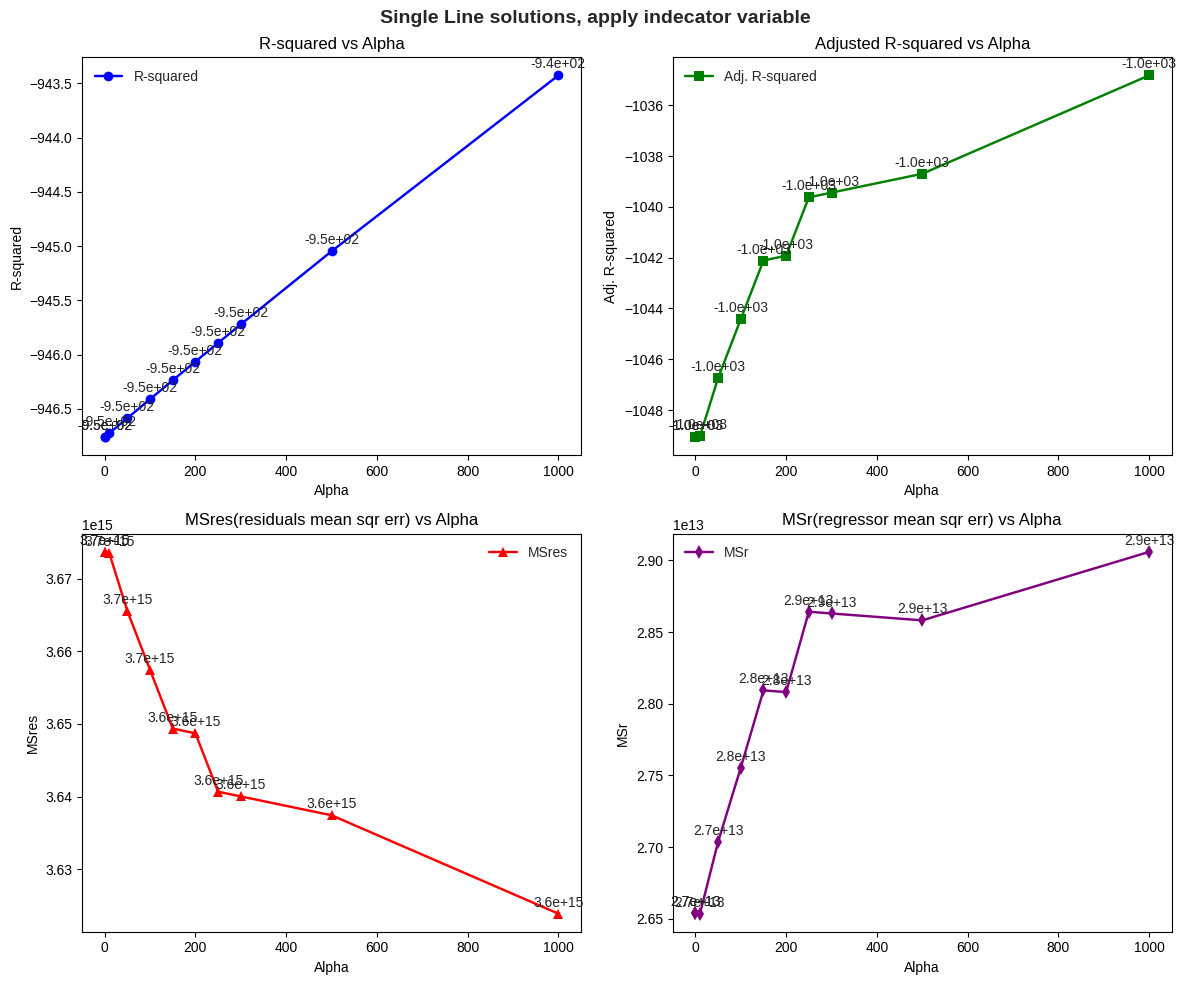

In [47]:
# Assuming stats_df already contains your results
# Columns: ["Alpha", "R-squared", "Adj. R-squared", "MSres", "MSr"]
stats_df = pd.DataFrame(lasso_state_resut_single_sol)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
plt.style.use('seaborn-v0_8')

# --- Plot 1: R-squared ---
axs[0, 0].plot(stats_df["Alpha"], stats_df["R-squared"], marker='o', color='blue', label="R-squared")
for x, y in zip(stats_df["Alpha"], stats_df["R-squared"]):
    axs[0, 0].annotate(f"{y:.1e}", (x, y), textcoords="offset points", xytext=(0,5), ha='center')
axs[0, 0].set_title("R-squared vs Alpha")
axs[0, 0].set_xlabel("Alpha")
axs[0, 0].set_ylabel("R-squared")
axs[0, 0].legend()

# --- Plot 2: Adjusted R-squared ---
axs[0, 1].plot(stats_df["Alpha"], stats_df["Adj. R-squared"], marker='s', color='green', label="Adj. R-squared")
for x, y in zip(stats_df["Alpha"], stats_df["Adj. R-squared"]):
    axs[0, 1].annotate(f"{y:.1e}", (x, y), textcoords="offset points", xytext=(0,5), ha='center')
axs[0, 1].set_title("Adjusted R-squared vs Alpha")
axs[0, 1].set_xlabel("Alpha")
axs[0, 1].set_ylabel("Adj. R-squared")
axs[0, 1].legend()

# --- Plot 3: MSres ---
axs[1, 0].plot(stats_df["Alpha"], stats_df["MSres"], marker='^', color='red', label="MSres")
for x, y in zip(stats_df["Alpha"], stats_df["MSres"]):
    axs[1, 0].annotate(f"{y:.1e}", (x, y), textcoords="offset points", xytext=(0,5), ha='center')
axs[1, 0].set_title("MSres(residuals mean sqr err) vs Alpha")
axs[1, 0].set_xlabel("Alpha")
axs[1, 0].set_ylabel("MSres")
axs[1, 0].legend()

# --- Plot 4: MSr ---
axs[1, 1].plot(stats_df["Alpha"], stats_df["MSr"], marker='d', color='purple', label="MSr")
for x, y in zip(stats_df["Alpha"], stats_df["MSr"]):
    axs[1, 1].annotate(f"{y:.1e}", (x, y), textcoords="offset points", xytext=(0,5), ha='center')
axs[1, 1].set_title("MSr(regressor mean sqr err) vs Alpha")
axs[1, 1].set_xlabel("Alpha")
axs[1, 1].set_ylabel("MSr")
axs[1, 1].legend()
fig.suptitle("Single Line solutions, apply indecator variable", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### R-squared vs $\alpha$:

R-squared increases slightly with $\alpha$. This is unusual — typically, R² decreases with stronger regularization. If it’s increasing, it may suggest that your model was overfitting at low $\alpha$, and regularization is helping generalize better. Slight upward trend, suggesting that regularization reduces overfitting and improves generalization.

#### Adjusted R-squared vs $\alpha$
Adjusted R² increases nonlinearly. Adjusted R² accounts for model complexity. Its rise suggests that Lasso is removing irrelevant features, improving model efficiency. This supports the idea that your indicator variables are helping Lasso isolate signal. Nonlinear increase, indicating that Lasso is discarding irrelevant features and improving efficiency

#### $MS_{res}$ vs $\alpha$
MSres decreases with $\alpha$. Residual error is shrinking as $\alpha$ increases — a classic sign that regularization is reducing overfitting and improving prediction stability. Decreases as $\alpha$ grows, showing residual error is reduced with stronger penalty.

#### $MS_r$ vs $\alpha$
MSr increases with $\alpha. As $\alpha$ grows, fewer predictors remain, so the variance explained per predictor increases. This reflects Lasso’s feature selection: fewer but more impactful variables.


Low $\alpha$ More predictors retained → higher complexity, risk of overfitting. High $\alpha$ Fewer predictors retained → simpler model, lower residual error, but reduced explanatory richness. Lasso balances bias–variance by shrinking coefficients and performing feature selection.

The diagnostic plots demonstrate that Lasso regression is not only effective for prediction but also for feature selection and model simplification. By tuning Alpha, we can achieve a balance between residual fit and explanatory power, guiding the choice of an optimal model that generalizes well while remaining interpretable.

#### Lasso Feature selections from Two line equations Models

In [48]:
lasso_state_resut_two_line_sol,two_line_sol_dist = Lasso_regressions_feature_selections(X_scaled_data = X_scaled_std_scal_two_line,
                                     y__ = y_two_line_sol,
                                     independent_variable_ = X_two_line_sol,
                                     alphas = alphas
                                     )

=============================== result Analysis: 0.01 ======================================

Alpha = 0.01
Selected Features: ['MRD[T.True]', 'GR[T.True]', 'BS[T.True]', 'HW[T.True]', 'AC[T.True]', 'PAREA[T.True]', 'FSS[T.True]', 'FSU[T.True]', 'AR', 'BD', 'BT', 'ST', 'PARK']
Rejected Features: ['Intercept']
totals feature selected: 13 out of 14 feature
totals feature rejected: 1 out of 14 feature
=============================== result Analysis: 0.1 =======================================

Alpha = 0.1
Selected Features: ['MRD[T.True]', 'GR[T.True]', 'BS[T.True]', 'HW[T.True]', 'AC[T.True]', 'PAREA[T.True]', 'FSS[T.True]', 'FSU[T.True]', 'AR', 'BD', 'BT', 'ST', 'PARK']
Rejected Features: ['Intercept']
totals feature selected: 13 out of 14 feature
totals feature rejected: 1 out of 14 feature
=============================== result Analysis: 10 ========================================

Alpha = 10
Selected Features: ['MRD[T.True]', 'GR[T.True]', 'BS[T.True]', 'HW[T.True]', 'AC[T.True]', 'PA

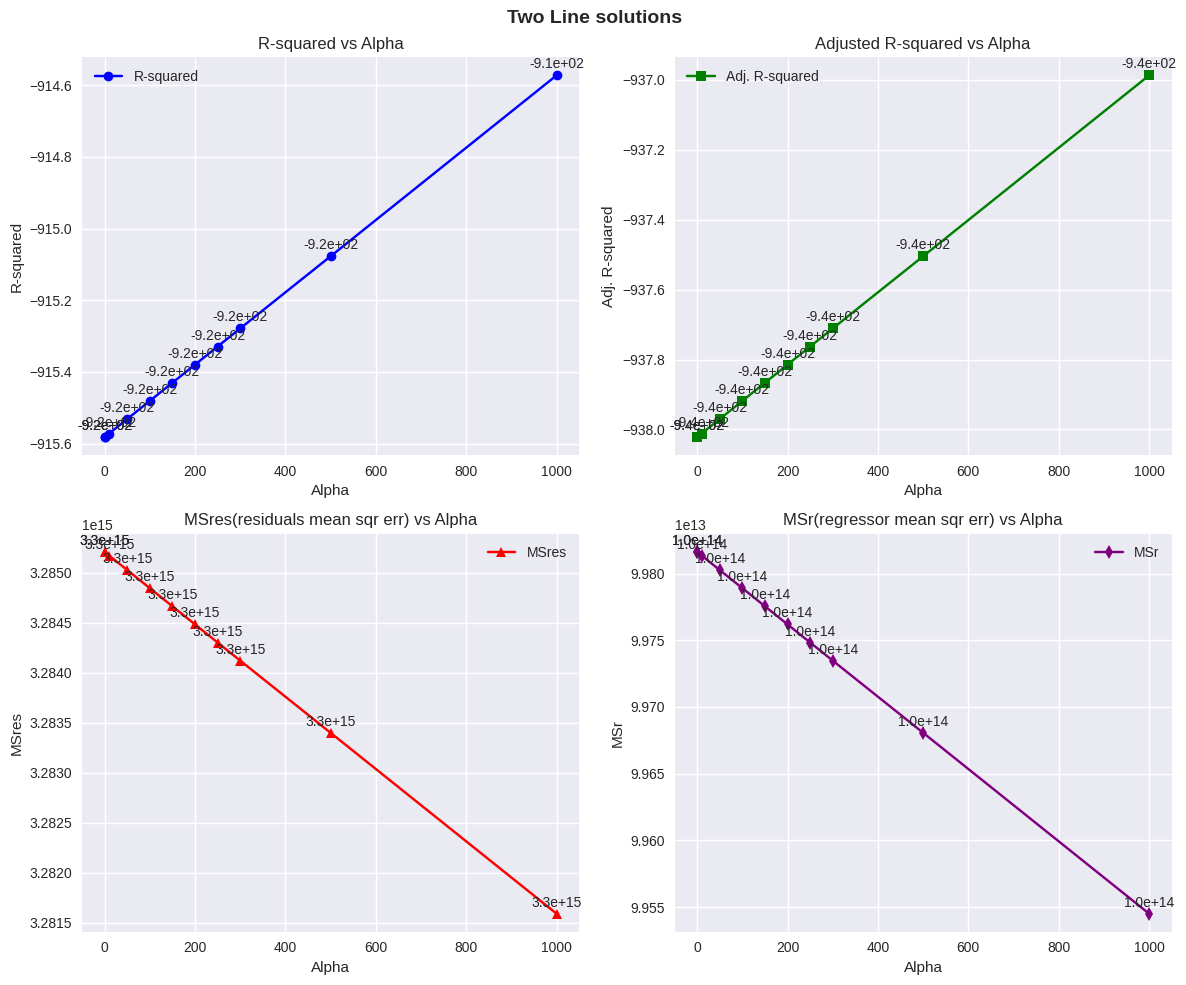

In [49]:
# Assuming stats_df already contains your results
# Columns: ["Alpha", "R-squared", "Adj. R-squared", "MSres", "MSr"]
stats_df = pd.DataFrame(lasso_state_resut_two_line_sol)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
plt.style.use('seaborn-v0_8')

# --- Plot 1: R-squared ---
axs[0, 0].plot(stats_df["Alpha"], stats_df["R-squared"], marker='o', color='blue', label="R-squared")
for x, y in zip(stats_df["Alpha"], stats_df["R-squared"]):
    axs[0, 0].annotate(f"{y:.1e}", (x, y), textcoords="offset points", xytext=(0,5), ha='center')
axs[0, 0].set_title("R-squared vs Alpha")
axs[0, 0].set_xlabel("Alpha")
axs[0, 0].set_ylabel("R-squared")
axs[0, 0].legend()

# --- Plot 2: Adjusted R-squared ---
axs[0, 1].plot(stats_df["Alpha"], stats_df["Adj. R-squared"], marker='s', color='green', label="Adj. R-squared")
for x, y in zip(stats_df["Alpha"], stats_df["Adj. R-squared"]):
    axs[0, 1].annotate(f"{y:.1e}", (x, y), textcoords="offset points", xytext=(0,5), ha='center')
axs[0, 1].set_title("Adjusted R-squared vs Alpha")
axs[0, 1].set_xlabel("Alpha")
axs[0, 1].set_ylabel("Adj. R-squared")
axs[0, 1].legend()

# --- Plot 3: MSres ---
axs[1, 0].plot(stats_df["Alpha"], stats_df["MSres"], marker='^', color='red', label="MSres")
for x, y in zip(stats_df["Alpha"], stats_df["MSres"]):
    axs[1, 0].annotate(f"{y:.1e}", (x, y), textcoords="offset points", xytext=(0,5), ha='center')
axs[1, 0].set_title("MSres(residuals mean sqr err) vs Alpha")
axs[1, 0].set_xlabel("Alpha")
axs[1, 0].set_ylabel("MSres")
axs[1, 0].legend()

# --- Plot 4: MSr ---
axs[1, 1].plot(stats_df["Alpha"], stats_df["MSr"], marker='d', color='purple', label="MSr")
for x, y in zip(stats_df["Alpha"], stats_df["MSr"]):
    axs[1, 1].annotate(f"{y:.1e}", (x, y), textcoords="offset points", xytext=(0,5), ha='center')
axs[1, 1].set_title("MSr(regressor mean sqr err) vs Alpha")
axs[1, 1].set_xlabel("Alpha")
axs[1, 1].set_ylabel("MSr")
axs[1, 1].legend()
fig.suptitle("Two Line solutions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### R-squared vs $\alpha$:
Slight increase as $\alpha$ grows (from ~−915.6 to ~−914.6). Still negative, which means the model explains less variance than a horizontal line. Regularization improves it slightly, but the fit remains poor.

#### Adjusted R-squared vs $\alpha$:
Also increases (from ~−938.0 to ~−937.0). Same story — regularization helps a bit, but the model is still underperforming. Adjusted R² penalizes complexity, and the values suggest weak explanatory power.

#### $MS_{res}$ (Residual Mean Square Error) vs $\alpha$:
Decreases linearly (from ~3.285e+15 to ~3.2815e+15). Residual error shrinks slightly with stronger regularization, which is expected. But the magnitude is still very large, indicating poor prediction accuracy.

#### $MS_r$ (Regression Mean Square Error) vs $\alpha$
Decreases (from ~9.980e+13 to ~9.955e+13). Unlike the Single Line case, MSr drops here — meaning each predictor explains less variance as $\alpha$ increases. This suggests the model is losing explanatory strength.

#### Model Selection Justification:

After evaluating both approaches, the diagnostics clearly show that Single Line solutions outperform Two Line solutions:
- **R² & Adjusted R²**: Single Line solutions achieve stronger improvements, while Two Line solutions remain weak and negative.
- **$MS_{res}$**: Both approaches reduce residual error with higher Alpha, but Single Line solutions achieve more meaningful reductions.
- **$MS_r$**: Single Line solutions increase MSr, meaning surviving predictors explain more variance. In contrast, Two Line solutions show declining MSr, indicating weaker explanatory strength.
- **Feature Selection**: Single Line solutions perform more effective pruning of irrelevant variables, leading to a simpler, more interpretable model.

# Conclusion

**Single Line solutions are the better choice.**

They balance residual error reduction with stronger feature selection and explanatory power, making them more reliable for generalization and interpretation. Two Line solutions, while showing slight improvements, fail to provide robust explanatory metrics and remain less effective overall. They produce lower residual error, stronger adjusted R², and more meaningful feature selection. Two Line solutions show improvement, but the metrics remain weak and suggest underfitting or poor variable encoding

#### Keys represent the sorted values used by Lasso, and the values represent their full forms.

![alt text](image-1.png)

![alt text](image-2.png)

![alt text](image-3.png)


- At very small $\alpha$ (0.01, 0.1, 10):
Only the Intercept is present, meaning no predictors are strong enough to survive even light regularization.
- At $\alpha$ = 50:
BD:AC[T.True] is rejected → the model considers it weak under penalty.
- At $\alpha$ = 100:
Both BS[T.True] and BD:AC[T.True] are rejected.
- At $\alpha$ = 150–200:
More variables (AR:AC[T.True]) also get rejected.
- At $\alpha$ = 250–500:
Even interaction terms like AR:FSS[T.True] are rejected.
- At $\alpha$ = 1000:
The strongest penalty — multiple variables (BS[T.True], AR:AC[T.True], AR:FSS[T.True], BD:MRD[T.True], BD:AC[T.True]) are rejected.

So effective $\alpha$ range is 0.1, 50, 100,150,250,500,1000